In [17]:
import matplotlib.pyplot as plt
import networkx as nx
from networkx.drawing.nx_pydot import graphviz_layout
import numpy as np
import os
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import pydot
import random
import seaborn as sns
import warnings

from reeb_utils import all_traj_same, collapse_traj, do_reeb_for_start_end, do_reeb_for_explore_node
from scipy import stats

warnings.filterwarnings("ignore")
pd.options.mode.chained_assignment = None

is there a metric for compressibility??
ie, to compare paths of two people. 
predictability? see how much this varies from peple to people
- surprisal


** compare to random walk **

* men v women sampling &  hypothesis test w ngram compression

## Random walker

In [ ]:
A - G
B - HC
C - BID
D - CJE
E - DMF
F - EN
G - AHL
H - GBQ
I - C
J - DKR
K - J
L - G
M - EOS
N - F
O - M
P - Z
Q - HRT
R - QJSU
S - MR
T - XQU
U - TRW
V - XY
W - U
X - ZTV
Y - V
Z - PX

In [159]:
def create_maze_graph():
    """Create graph from the given adjacency list"""
    connections = {
        'A': ['G'],
        'B': ['H', 'C'],
        'C': ['B', 'I', 'D'],
        'D': ['C', 'J', 'E'],
        'E': ['D', 'M', 'F'],
        'F': ['E', 'N'],
        'G': ['A', 'H', 'L'],
        'H': ['G', 'B', 'Q'],
        'I': ['C'],
        'J': ['D', 'K', 'R'],
        'K': ['J'],
        'L': ['G'],
        'M': ['E', 'O', 'S'],
        'N': ['F'],
        'O': ['M'],
        'P': ['Z'],
        'Q': ['H', 'R', 'T'],
        'R': ['Q', 'J', 'S', 'U'],
        'S': ['M', 'R'],
        'T': ['X', 'Q', 'U'],
        'U': ['T', 'R', 'W'],
        'V': ['X', 'Y'],
        'W': ['U'],
        'X': ['Z', 'T', 'V'],
        'Y': ['V'],
        'Z': ['P', 'X']
    }
    return connections

def random_walk(graph, start_node, n_steps):
    """
    Perform a random walk on the graph
    
    Parameters:
    -----------
    graph : dict
        Adjacency list representation of the graph
    start_node : str
        Starting node for the walk
    n_steps : int
        Number of steps to take
        
    Returns:
    --------
    list
        Sequence of nodes visited during the walk
    """
    current_node = start_node
    trajectory = [current_node]
    
    for _ in range(n_steps):
        # Get possible next nodes
        neighbors = graph[current_node]
        
        # Randomly select next node
        current_node = random.choice(neighbors)
        trajectory.append(current_node)
    
    return trajectory

# Example usage:
graph = create_maze_graph()
trajectory = random_walk(graph, start_node='A', n_steps=20)
print("Example random walk:", ''.join(trajectory))

# Generate multiple trajectories
n_trajectories = 5
print("\nMultiple random walks:")
for i in range(n_trajectories):
    traj = random_walk(graph, start_node='A', n_steps=20)
    print(f"Walk {i+1}: {''.join(traj)}")

Example random walk: AGAGAGHQHGHQTURJRSRQR

Multiple random walks:
Walk 1: AGHGHGAGAGHGAGLGLGHQR
Walk 2: AGAGLGHQHBCDJRURSMOMS
Walk 3: AGHQTUWURSRSMEDCDJDCB
Walk 4: AGAGLGHQRJDCICDCICICD
Walk 5: AGAGLGAGAGAGHQRQRSRSM


In [104]:
# load data into dataframe
df = pd.read_csv("data/MLINDIV_train_full.csv")

test_df = df[df["eprocs"].str.contains("Test")]

test_df["subj_mean_acc"] = test_df.groupby("Subject")["accuracy"].transform("mean")
test_df["path_mean_acc"] = test_df.groupby(["StartAt", "EndAt"])["accuracy"].transform("mean")

test_df['quartile'] = (
    pd.qcut(test_df['subj_mean_acc'], 4, labels=[1, 2, 3, 4])
)

test_df["path_mean_acc_by_Q"] = test_df.groupby(["StartAt", "EndAt", "quartile"])["accuracy"].transform("mean")

## EXPLORE DF
explore_df = df[df["eprocs"].str.contains("Explore")]

# By quartile
q_dict = {}
acc_dict = {}
for index, row in test_df[["Subject", "quartile", "subj_mean_acc"]].iterrows():
    subj, q, acc = row["Subject"], row["quartile"], row["subj_mean_acc"]
    if subj not in q_dict:
        q_dict[subj] = q
        acc_dict[subj] = acc

explore_df["quartile"] = explore_df["Subject"].map(q_dict)
explore_df["subject_mean_acc"] = explore_df["Subject"].map(acc_dict)

def compute_extended_explore_traj(e_path):
    # need to replace V-east (V2) with Y and F-south (F3) with N
    # because they are facing and can see the object from there
    path = e_path.replace("V2", "Y2")
    path = e_path.replace("F3", "N3")
    
    nodes = path.split()
    nodes.remove("NA")
    nodes = [n[0] for n in nodes]

    return "".join(nodes)
    
def compute_explore_traj(e_path):
    # need to replace V-east (V2) with Y and F-south (F3) with N
    # because they are facing and can see the object from there
    path = e_path.replace("V2", "Y2")
    path = e_path.replace("F3", "N3")
    
    nodes = path.split()
    nodes.remove("NA")
    nodes = [n[0] for n in nodes]

    return "".join(collapse_traj(nodes))

# concatenate explore rounds for now
explore_df["explore_path"] = explore_df.groupby("Subject")["e_paths"].transform(" # ".join)
explore_df = explore_df.drop_duplicates(subset=["Subject"], keep="first")

explore_df["extended_explore_traj"] = explore_df["explore_path"].apply(compute_extended_explore_traj)
explore_df["explore_traj"] = explore_df["explore_path"].apply(compute_explore_traj)
explore_df["num_nodes_visited"] = explore_df["explore_traj"].apply(len)

explore_df[["explore_traj", "quartile", "subject_mean_acc"]]

,explore_traj,quartile,subject_mean_acc
0,URQTXVXZPZXTQHGLGAGHBCICDEMOMSRUTXTUWUTXVYVXZP...,3.0,0.916667
50,RSMOMEDJKJRUWUTQRQTXVYVXZPZXTQHGLGAGHBCICDEMOM...,4.0,1.000000
100,URQTXZPZXVXTURSMEFNFEDCICBHQHGAGLGHBCDJRJKJRUR...,2.0,0.375000
110,UWURSMEFNFEDCBHGLGHGAGHQTXVYVXZPZXTUWURQHGAGLG...,3.0,0.791667
160,DJRUWUTXVYVXZPZXTQRSMEFNFEDJRQHGLGAGHQTXVXZXTU...,1.0,0.229167
...,...,...,...
4837,RJDCBHQTXVYVXTURJDEFNFEDCBHQTXVXZPZXTUWURSMEDC...,1.0,0.125000
4887,URJDCBHGAGLGHQTXZPZXVXTUWURSMEFNFEDCBHGAGHQRJK...,2.0,0.375000
4937,DJKJRQHBHGAGHQTXVYVXTQRSMOMSRJDEFNFEMSRUWUTXVX...,2.0,0.416667
4987,RJDCICDEMOMSRJKJDCBHGLGHQRUWUTXVYVXZPZXTQHGAGL...,3.0,0.854167


In [3]:

from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter
import re

# Function to generate n-grams from a string
def get_ngrams(text, n):
    # Convert string into list of characters
    chars = list(text)
    # Generate n-grams
    ngrams = zip(*[chars[i:] for i in range(n)])
    return [''.join(ngram) for ngram in ngrams]

# Function to find most common motifs
def analyze_motifs(trajectories, n_range=(2,5), top_k=10):
    motifs_by_length = {}
    
    for n in range(n_range[0], n_range[1] + 1):
        all_ngrams = []
        for traj in trajectories:
            all_ngrams.extend(get_ngrams(traj, n))
        
        # Count frequencies
        motif_counts = Counter(all_ngrams)
        most_common = motif_counts.most_common(top_k)
        motifs_by_length[n] = most_common
    
    return motifs_by_length

# Analyze the trajectories
motifs = analyze_motifs(explore_df['explore_traj'].values)

# Print results
for n, common_motifs in motifs.items():
    print(f"\nMost common {n}-length motifs:")
    for motif, count in common_motifs:
        print(f"{motif}: {count} occurrences")

# Alternative: Using sklearn's CountVectorizer for more sophisticated tokenization
vectorizer = CountVectorizer(
    analyzer='char',
    ngram_range=(2, 5),  # analyze 2-5 character sequences
    min_df=5  # minimum number of documents (trajectories) a token must appear in
)

# Fit and transform the trajectories
X = vectorizer.fit_transform(explore_df['explore_traj'])

# Get feature names (tokens) and their frequencies
token_frequencies = zip(vectorizer.get_feature_names_out(), X.sum(axis=0).A1)
top_tokens = sorted(token_frequencies, key=lambda x: x[1], reverse=True)[:20]

print("\nTop 20 movement patterns using sklearn tokenization:")
for token, freq in top_tokens:
    print(f"{token}: {freq} occurrences")


Most common 2-length motifs:
TX: 495 occurrences
XT: 472 occurrences
HG: 465 occurrences
XV: 463 occurrences
VX: 455 occurrences
GH: 450 occurrences
UW: 433 occurrences
WU: 426 occurrences
GA: 404 occurrences
AG: 401 occurrences

Most common 3-length motifs:
UWU: 426 occurrences
GAG: 401 occurrences
MOM: 377 occurrences
GLG: 367 occurrences
EFN: 366 occurrences
FNF: 365 occurrences
XZP: 363 occurrences
ZPZ: 359 occurrences
PZX: 357 occurrences
NFE: 352 occurrences

Most common 4-length motifs:
XZPZ: 359 occurrences
ZPZX: 357 occurrences
EFNF: 357 occurrences
FNFE: 352 occurrences
HGAG: 267 occurrences
GLGH: 227 occurrences
TUWU: 224 occurrences
PZXT: 218 occurrences
GAGH: 215 occurrences
UWUR: 214 occurrences

Most common 5-length motifs:
XZPZX: 357 occurrences
EFNFE: 345 occurrences
ZPZXT: 218 occurrences
VXZPZ: 207 occurrences
XVYVX: 201 occurrences
MEFNF: 197 occurrences
RSMOM: 185 occurrences
GAGLG: 181 occurrences
FNFED: 180 occurrences
HGAGL: 179 occurrences

Top 20 movement pat

In [173]:
def get_trajectory_data(source_type, explore_df, graph):
    """Get trajectory data based on source type."""
    if source_type == "top_quartile":
        return "".join(explore_df[explore_df['quartile'] == 4]['explore_traj'].values)
    elif source_type == "bottom_quartile":
        return "".join(explore_df[explore_df['quartile'] == 1]['explore_traj'].values)
    elif source_type == "random_walk":
        return "".join(random_walk(graph, start_node='A', n_steps=10000))
    else:
        raise ValueError("Invalid source type")

def process_ngrams(trajectory, n, top_k=None):
    """Process n-grams and return sorted, filtered counts."""
    ngrams = get_ngrams(trajectory, n)
    ngram_counts = Counter(ngrams)
    filtered = {k: v for k, v in ngram_counts.items() if '#' not in k and ' ' not in k}
    sorted_counts = dict(sorted(filtered.items(), key=lambda x: x[1], reverse=True))
    if top_k:
        return dict(list(sorted_counts.items())[:top_k])
    return sorted_counts

def create_bar_trace(data_dict, highlight_nodes, row, col):
    """Create a bar trace with appropriate coloring."""
    colors = ['red' if any(node in highlight_nodes for node in ngram) else 'blue' 
              for ngram in data_dict.keys()]
    
    return go.Bar(
        x=list(data_dict.keys()),
        y=list(data_dict.values()),
        marker_color=colors,
        showlegend=(row == 1 and col == 1),  # Only show legend for first plot
        name='Nodes' if col == 1 else 'Bigrams' if col == 2 else 'Trigrams' if col == 3 else 'Fourgrams'
    )

# Create figure with 3x4 subplots
fig = make_subplots(
    rows=3, cols=4,
    subplot_titles=('Unigrams (Top Q)', 'Bigrams (Top Q)', 'Trigrams (Top Q)', 'Fourgrams (Top Q)',
                   'Unigrams (Bottom Q)', 'Bigrams (Bottom Q)', 'Trigrams (Bottom Q)', 'Fourgrams (Bottom Q)',
                   'Unigrams (Random)', 'Bigrams (Random)', 'Trigrams (Random)', 'Fourgrams (Random)'),
    vertical_spacing=0.1
)

highlight_nodes = set('ALIKNOPWY')
source_types = ["top_quartile", "bottom_quartile", "random_walk"]

# Process each source type (creates one row of plots)
for row_idx, source_type in enumerate(source_types, 1):
    # Get trajectory data
    trajs_to_plot = get_trajectory_data(source_type, explore_df, graph)
    
    # Create each type of n-gram plot
    unigrams = process_ngrams(trajs_to_plot, 1)
    bigrams = process_ngrams(trajs_to_plot, 2)
    trigrams = process_ngrams(trajs_to_plot, 3)#, top_k=20)
    fourgrams = process_ngrams(trajs_to_plot, 4)#, top_k=20)
    
    # Add traces for each n-gram type
    for col_idx, ngrams in enumerate([unigrams, bigrams, trigrams, fourgrams], 1):
        trace = create_bar_trace(ngrams, highlight_nodes, row_idx, col_idx)
        fig.add_trace(trace, row=row_idx, col=col_idx)

# Add dummy traces for legend
fig.add_trace(
    go.Bar(x=[None], y=[None], name='Regular Nodes', marker_color='blue',
           showlegend=True),
    row=1, col=1
)
fig.add_trace(
    go.Bar(x=[None], y=[None], name='Object-containing', marker_color='red',
           showlegend=True),
    row=1, col=1
)

# Update layout
fig.update_layout(
    height=1500,  # Increased height for 3 rows
    width=2000,
    showlegend=True,
    title_text="N-gram Distributions by Group"
)

# Update all x-axes
for row in range(1, 4):
    for col in range(1, 5):
        fig.update_xaxes(tickangle=45, row=row, col=col)
        if col == 1:  # Only add y-axis title for first column
            fig.update_yaxes(title_text="Frequency", row=row, col=col)

fig.show()

### Util functions ###

In [9]:
def generate_reeb_tree(start_i, start_node, trajs, which_trajs, G, visited, SUCCESS="", DEBUG=False):
    """Generates Reeb tree.

    TODO talk about what this means

    Parameters
    ----------
    start_i : TODO,
        TODO
    start_node : TODO,
        TODO
    trajs : list,
        Shape = [n_trajs, various]
        List of all trajectories over which to compute the Reeb tree.
    G : nx.Graph,
        Reeb tree to mutate in place as graph is construted.
    visited : TODO,
        TODO
    DEBUG : boolean,
        If True print more things.

    Returns
    -------
    None
    """
    if DEBUG: print(f"DO REEB, {start_i}, {start_node}, {which_trajs}")
    times_before = visited.get(start_node, 0) 
    visited[start_node] = times_before
    to_add = start_node + "_" + str(times_before)

    max_traj_len = max([len(trajs[t]) for t in which_trajs])

    ## BASE CASE 1: SINGLETON ##
    ## BASE CASE 2: ALL THE SAME ##
    if len(which_trajs) == 1 or all_traj_same(trajs, which_trajs, max_traj_len):
        end_node = trajs[which_trajs[0]][-1]
        times_before = visited.get(end_node, -1) + 1
        visited[end_node] = times_before
        
        end_node +=  "_" + str(times_before)
        if DEBUG: print(f"BASE CASE: {which_trajs}, last: {end_node}")

        color = "green" if SUCCESS in end_node else "yellow"
        G.add_node(end_node, color=color, end=True)
        G.add_edge(to_add, end_node, weight=len(which_trajs) / len(trajs))

        return
    

    ## RECURSIVE STEP ##
    if DEBUG: print(f"FOR LOOP, {start_i}, {which_trajs}")
    for step in range(start_i, max_traj_len):
        
        new_gn = {}
        for i in which_trajs:
            traj = trajs[i]

            ## STOPPING CONDITION FOR THIS ONE GUY ##
            if step >= len(traj): 
                new_gn["DONE"] = new_gn.get("DONE", []).copy() + [i]
            else:
                new_node = traj[step]     
                new_gn[new_node] = new_gn.get(new_node, []).copy() + [i]

        if DEBUG: print("NEW_GN", new_gn)
        # decide whether we need a reeb node
        
        # people went different ways!!
        if len(new_gn.keys()) > 1:
            times_before = visited.get(start_node, 0)
            sn = start_node + "_" + str(times_before)
            
            

            if DEBUG: print("VISITED", visited)
            
            for k, v in new_gn.items():
                if DEBUG: print("RECURSE")

                # the thing happened at the node before this! all the paths in this fn are at the same point there so it doesnt mattter
                old_one = k#trajs[which_trajs[0]][step-1]
                times_before = visited.get(old_one, -1) + 1
                visited[old_one] = times_before

                

                on = k + "_" + str(times_before)
                G.add_node(on, color="blue", end=False)
                if DEBUG: print(f"ADDING NEW BLUE NODE {on}")
                
                G.add_edge(sn, on, weight=len(which_trajs) / len(trajs))
                if DEBUG: print(f"ADDING NEW EDGE from {sn} to {on}, weight is {len(which_trajs)}")

                if DEBUG and k == "DONE":
                    print("*@#)$*$#()*(#@($")
                    print(new_gn)
                    
                generate_reeb_tree(step+1, old_one, trajs,  v, G, visited, SUCCESS=SUCCESS, DEBUG=DEBUG)

            return

In [155]:
def find_when_all_objects_found(traj):    
    OBJECTS = "ALPIKNOWY" 
    # could take max of [traj.index(obj) for obj in OBJECTS]
    # but raises ValueError if obj not found & is slower bc runs through list multiple times

    for i, node in enumerate(traj):
        if node in OBJECTS:
            OBJECTS = OBJECTS.replace(node, "")
            
            # found all objects
            if len(OBJECTS) == 0:
                return i
    return "DNF-" + str(OBJECTS)

explore_df["all_objects_found_idx"] = explore_df["extended_explore_traj"].apply(find_when_all_objects_found)

# print(explore_df[["extended_explore_traj", "e_paths", "quartile", "subject_mean_acc", "all_objects_found_idx"]])


In [22]:
def plot_treeb(G):
    fig = plt.figure(figsize=(10,5))
    this_ax = plt.gca()

    pos = graphviz_layout(G, prog="dot")
    
    edges = G.edges()
    weights = [G[u][v]['weight'] * 2 for u,v in edges]

    nodes = G.nodes()
    # for n in nodes:
    #     print(n, G.nodes[n])
    n_labels = {n: n for n in G}
    n_colors = [G.nodes[n].get("color", "blue") for n in nodes]
    # print(n_colors)
    # print ((q-1) // 2, (q-1) % 2)
    # nx.draw_networkx_nodes(G, pos, node_color=n_colors, node_size=500, alpha=0.7, ax=this_ax)
    nx.draw_networkx_edges(G, pos, edgelist=edges, width=weights, ax=this_ax)
    # nx.draw_networkx_labels(G, pos, labels=n_labels, font_size=13, ax=this_ax) # font_weight="bold",

    this_ax.axis("off")
    plt.show()

In [34]:
def extract_tree_features(graph, root):
    # Number of Nodes
    num_nodes = graph.number_of_nodes()
    
    # Number of Edges
    num_edges = graph.number_of_edges()
    
    # Tree Depth (Height)
    def tree_depth(graph, root):
        depths = nx.single_source_shortest_path_length(graph, root)
        return max(depths.values())
    
    depth = tree_depth(graph, root)
    
    # Average Node Degree
    avg_degree = np.mean([degree for node, degree in graph.degree()])
    
    # Diameter
    diameter = nx.diameter(graph)
    
    # Number of Leaves
    num_leaves = sum(1 for node in graph.nodes() if graph.degree(node) == 1)
    
    # Average Path Length
    avg_path_length = nx.average_shortest_path_length(graph)
    
    # Branching Factor
    branching_factors = [len(list(graph.neighbors(node))) for node in graph.nodes()]
    avg_branching_factor = np.mean(branching_factors)
    
    # Put all features in a list
    features = [
        num_nodes,
        num_edges,
        depth,
        avg_degree,
        diameter,
        num_leaves,
        avg_path_length,
        avg_branching_factor
    ]
    
    return features

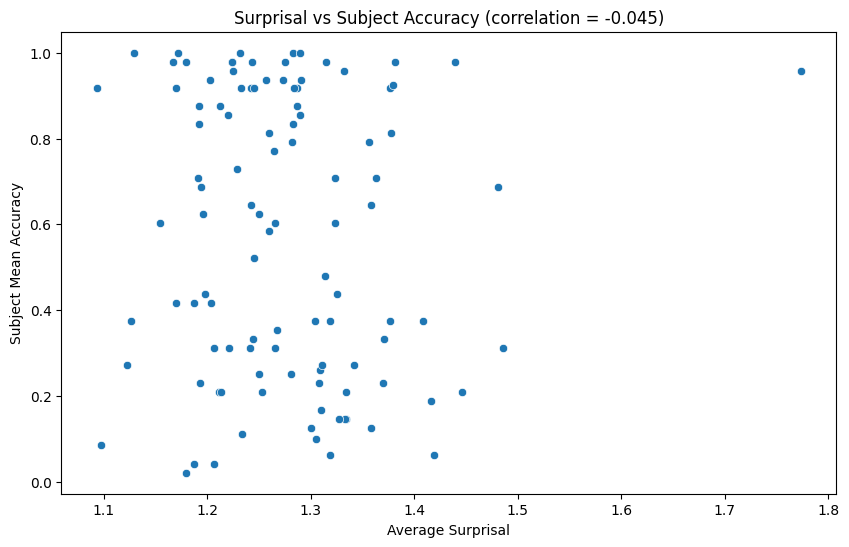


Mean Surprisal by Performance Quartile:
quartile
1.0    1.284110
2.0    1.268104
3.0    1.268802
4.0    1.285767
Name: surprisal, dtype: float64

One-way ANOVA:
F-statistic: 0.259
p-value: 0.855


In [146]:
# Calculate transition probabilities for the entire dataset
def calculate_surprisal(trajectory, transition_probs):
    """Calculate average surprisal for a trajectory using transition probabilities"""
    surprisal = 0
    count = 0
    
    # For each token in trajectory (except last)
    for i in range(len(trajectory)-1):
        current = trajectory[i]
        next_token = trajectory[i+1]
        
        # Get probability of this transition
        if current in transition_probs and next_token in transition_probs[current]['probs']:
            prob = transition_probs[current]['probs'][next_token]
            # Surprisal is -log2(probability)
            surprisal += -np.log2(prob)
            count += 1
    
    # Return average surprisal per transition
    return surprisal / count if count > 0 else 0

# Get transition probabilities for entire dataset
trans_probs = compute_transition_probabilities(explore_df['explore_traj'].values, window_size=1)

# Calculate surprisal for each trajectory
explore_df['surprisal'] = explore_df['explore_traj'].apply(
    lambda x: calculate_surprisal(x, trans_probs)
)

# Calculate correlation with subject accuracy
correlation = explore_df['surprisal'].corr(explore_df['subject_mean_acc'])

# Visualize relationship
plt.figure(figsize=(10, 6))
sns.scatterplot(data=explore_df, x='surprisal', y='subject_mean_acc')
plt.title(f'Surprisal vs Subject Accuracy (correlation = {correlation:.3f})')
plt.xlabel('Average Surprisal')
plt.ylabel('Subject Mean Accuracy')
plt.show()

# Print summary statistics by quartile
print("\nMean Surprisal by Performance Quartile:")
print(explore_df.groupby('quartile')['surprisal'].mean())

# Run statistical test
from scipy import stats
f_stat, p_val = stats.f_oneway(*[group['surprisal'].values 
                                for name, group in explore_df.groupby('quartile')])
print(f"\nOne-way ANOVA:")
print(f"F-statistic: {f_stat:.3f}")
print(f"p-value: {p_val:.3f}")


## PRedictability

In [147]:
def lz_complexity(sequence):
    """Calculate Lempel-Ziv complexity of a sequence"""
    i, k, l = 0, 1, 1
    n = len(sequence)
    complexity = 1
    
    while k + l <= n:
        substring = sequence[k:k + l]
        substring0 = sequence[0:k + l - 1]
        
        if substring in substring0:
            l += 1
        else:
            k += l
            l = 1
            complexity += 1
    
    return complexity

# Apply to trajectories
explore_df['lz_complexity'] = explore_df['explore_traj'].apply(lz_complexity)

In [148]:
def ngram_entropy(sequence, n=2):
    """Calculate entropy of n-gram distributions"""
    ngrams = [''.join(sequence[i:i+n]) for i in range(len(sequence)-n+1)]
    freqs = Counter(ngrams)
    probs = [count/len(ngrams) for count in freqs.values()]
    return -sum(p * np.log2(p) for p in probs)

explore_df['bigram_entropy'] = explore_df['explore_traj'].apply(lambda x: ngram_entropy(x, 2))
explore_df['trigram_entropy'] = explore_df['explore_traj'].apply(lambda x: ngram_entropy(x, 3))

In [149]:
import zlib

def compression_ratio(sequence):
    """Calculate compression ratio using zlib"""
    byte_seq = sequence.encode('utf-8')
    compressed = zlib.compress(byte_seq)
    return len(compressed) / len(byte_seq)

explore_df['compression_ratio'] = explore_df['explore_traj'].apply(compression_ratio)

In [150]:
def markov_predictability(sequence, order=1):
    """Calculate predictability based on Markov chain transitions"""
    transitions = defaultdict(Counter)
    
    for i in range(len(sequence)-order):
        state = sequence[i:i+order]
        next_state = sequence[i+order]
        transitions[state][next_state] += 1
    
    # Calculate average predictability
    total_pred = 0
    count = 0
    for state, next_states in transitions.items():
        total = sum(next_states.values())
        probs = [count/total for count in next_states.values()]
        pred = max(probs)  # Use highest probability as predictability measure
        total_pred += pred
        count += 1
    
    return total_pred/count if count > 0 else 0

explore_df['markov_pred'] = explore_df['explore_traj'].apply(
    lambda x: markov_predictability(x, order=2)
)

In [151]:
from bz2 import compress

def kolmogorov_complexity(sequence):
    """Approximate Kolmogorov complexity using bzip2 compression"""
    return len(compress(sequence.encode('utf-8')))

explore_df['kolmogorov'] = explore_df['explore_traj'].apply(kolmogorov_complexity)

In [152]:
def repeat_pattern_score(sequence, min_len=2, max_len=5):
    """Calculate score based on repeated patterns"""
    total_repeats = 0
    for length in range(min_len, max_len+1):
        patterns = [''.join(sequence[i:i+length]) 
                   for i in range(len(sequence)-length+1)]
        pattern_counts = Counter(patterns)
        total_repeats += sum(count-1 for count in pattern_counts.values() if count > 1)
    return total_repeats

explore_df['repeat_score'] = explore_df['explore_traj'].apply(repeat_pattern_score)

Each of these metrics captures different aspects of sequence predictability:
LZ complexity focuses on unique subsequences
Entropy measures uncertainty/randomness
Compression ratio captures overall redundancy
Markov predictability looks at local transitions
Kolmogorov complexity approximates minimal description length
Repeat patterns directly measure sequence regularity
We can see which metrics correlate best with performance and potentially combine them for a more comprehensive measure.

Correlations with subject accuracy:
lz_complexity: -0.103
bigram_entropy: 0.202
trigram_entropy: -0.031
compression_ratio: -0.260
markov_pred: 0.170
kolmogorov: -0.022
repeat_score: 0.153


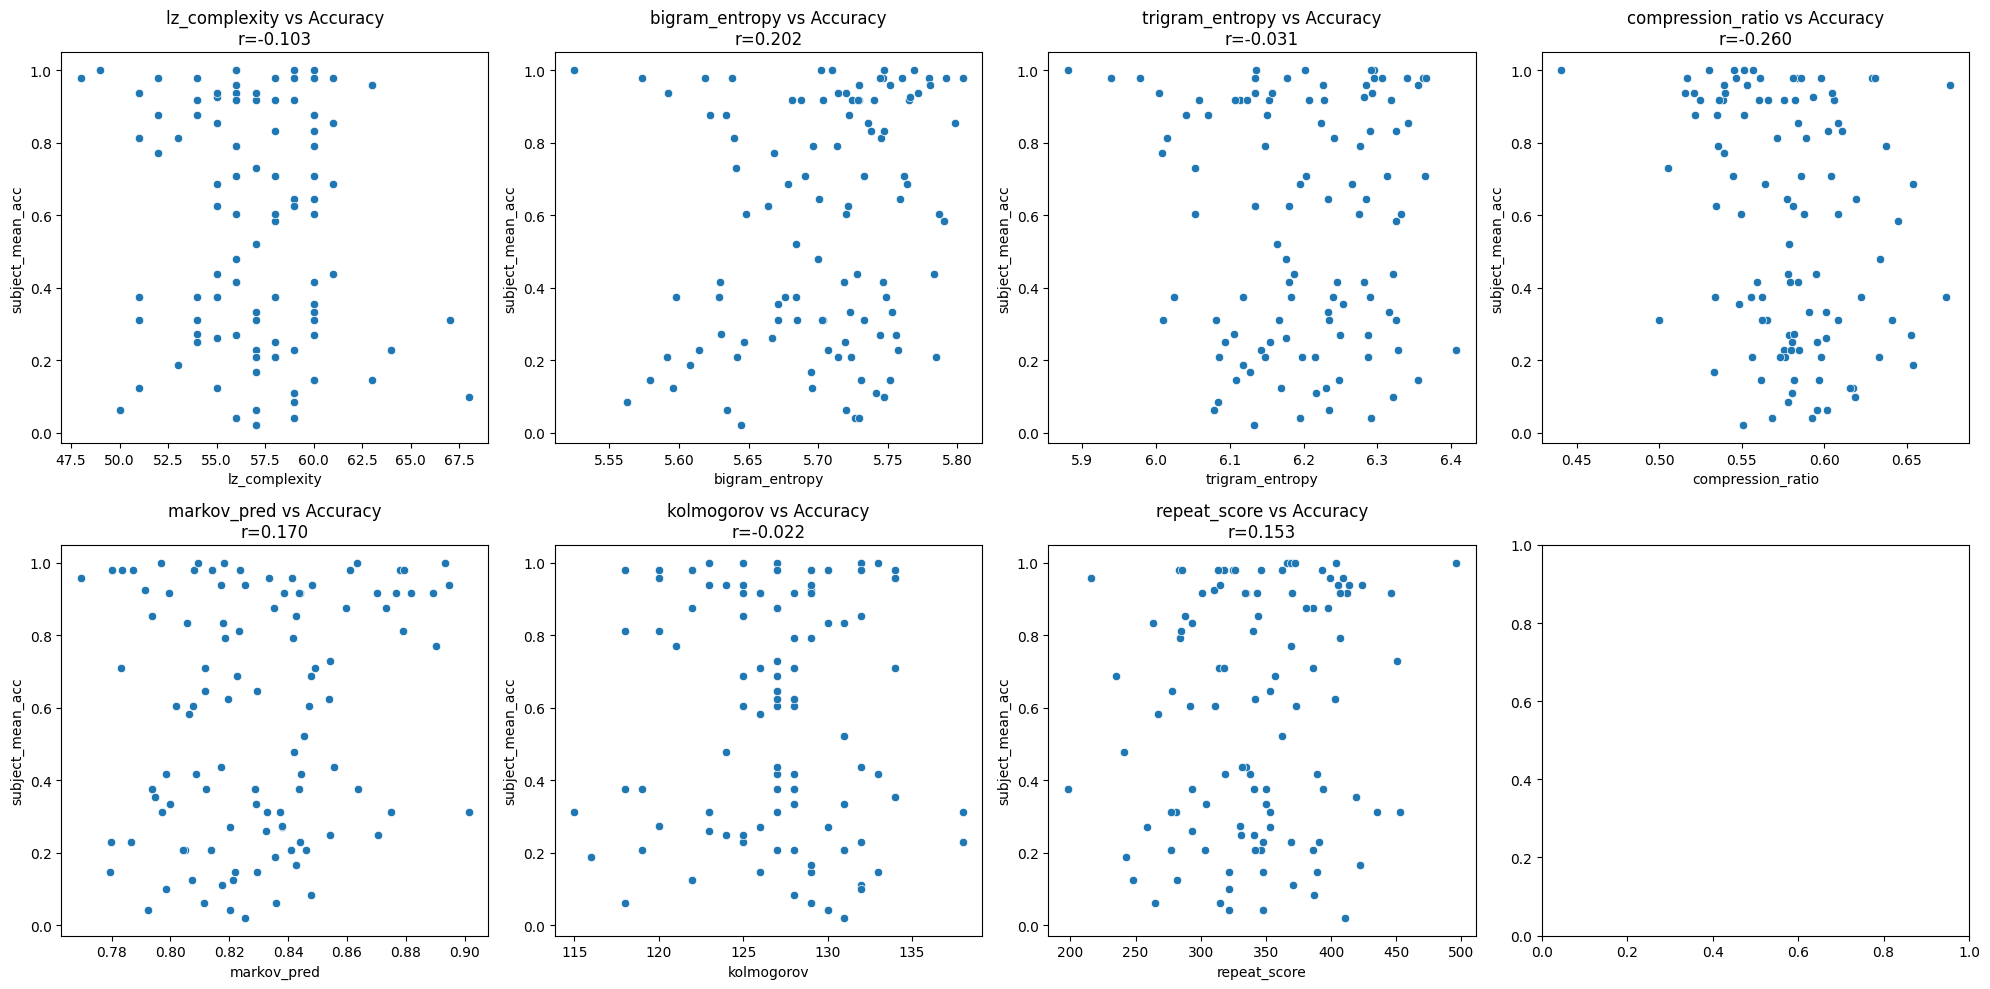

In [153]:
# Calculate correlations with subject_mean_acc
metrics = ['lz_complexity', 'bigram_entropy', 'trigram_entropy', 
           'compression_ratio', 'markov_pred', 'kolmogorov', 'repeat_score']

correlations = {metric: explore_df[metric].corr(explore_df['subject_mean_acc']) 
               for metric in metrics}

# Print correlations
print("Correlations with subject accuracy:")
for metric, corr in correlations.items():
    print(f"{metric}: {corr:.3f}")

# Visualize relationships
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for i, metric in enumerate(metrics):
    sns.scatterplot(data=explore_df, x=metric, y='subject_mean_acc', ax=axes[i])
    axes[i].set_title(f'{metric} vs Accuracy\nr={correlations[metric]:.3f}')

plt.tight_layout()
plt.show()

# check before v after
# both overall and pairwise 

Statistical tests comparing before vs after metrics:

lz_complexity:
Mean before: 54.533
Mean after: 52.348
t-statistic: 0.771
p-value: 0.443

bigram_entropy:
Mean before: 5.846
Mean after: 5.673
t-statistic: 3.146
p-value: 0.002

trigram_entropy:
Mean before: 6.491
Mean after: 6.303
t-statistic: 2.454
p-value: 0.016

compression_ratio:
Mean before: 0.685
Mean after: 0.695
t-statistic: -0.303
p-value: 0.763

markov_pred:
Mean before: 0.854
Mean after: 0.860
t-statistic: -1.006
p-value: 0.317

kolmogorov:
Mean before: 131.022
Mean after: 127.609
t-statistic: 0.600
p-value: 0.550

repeat_score:
Mean before: 238.522
Mean after: 247.880
t-statistic: -0.268
p-value: 0.789


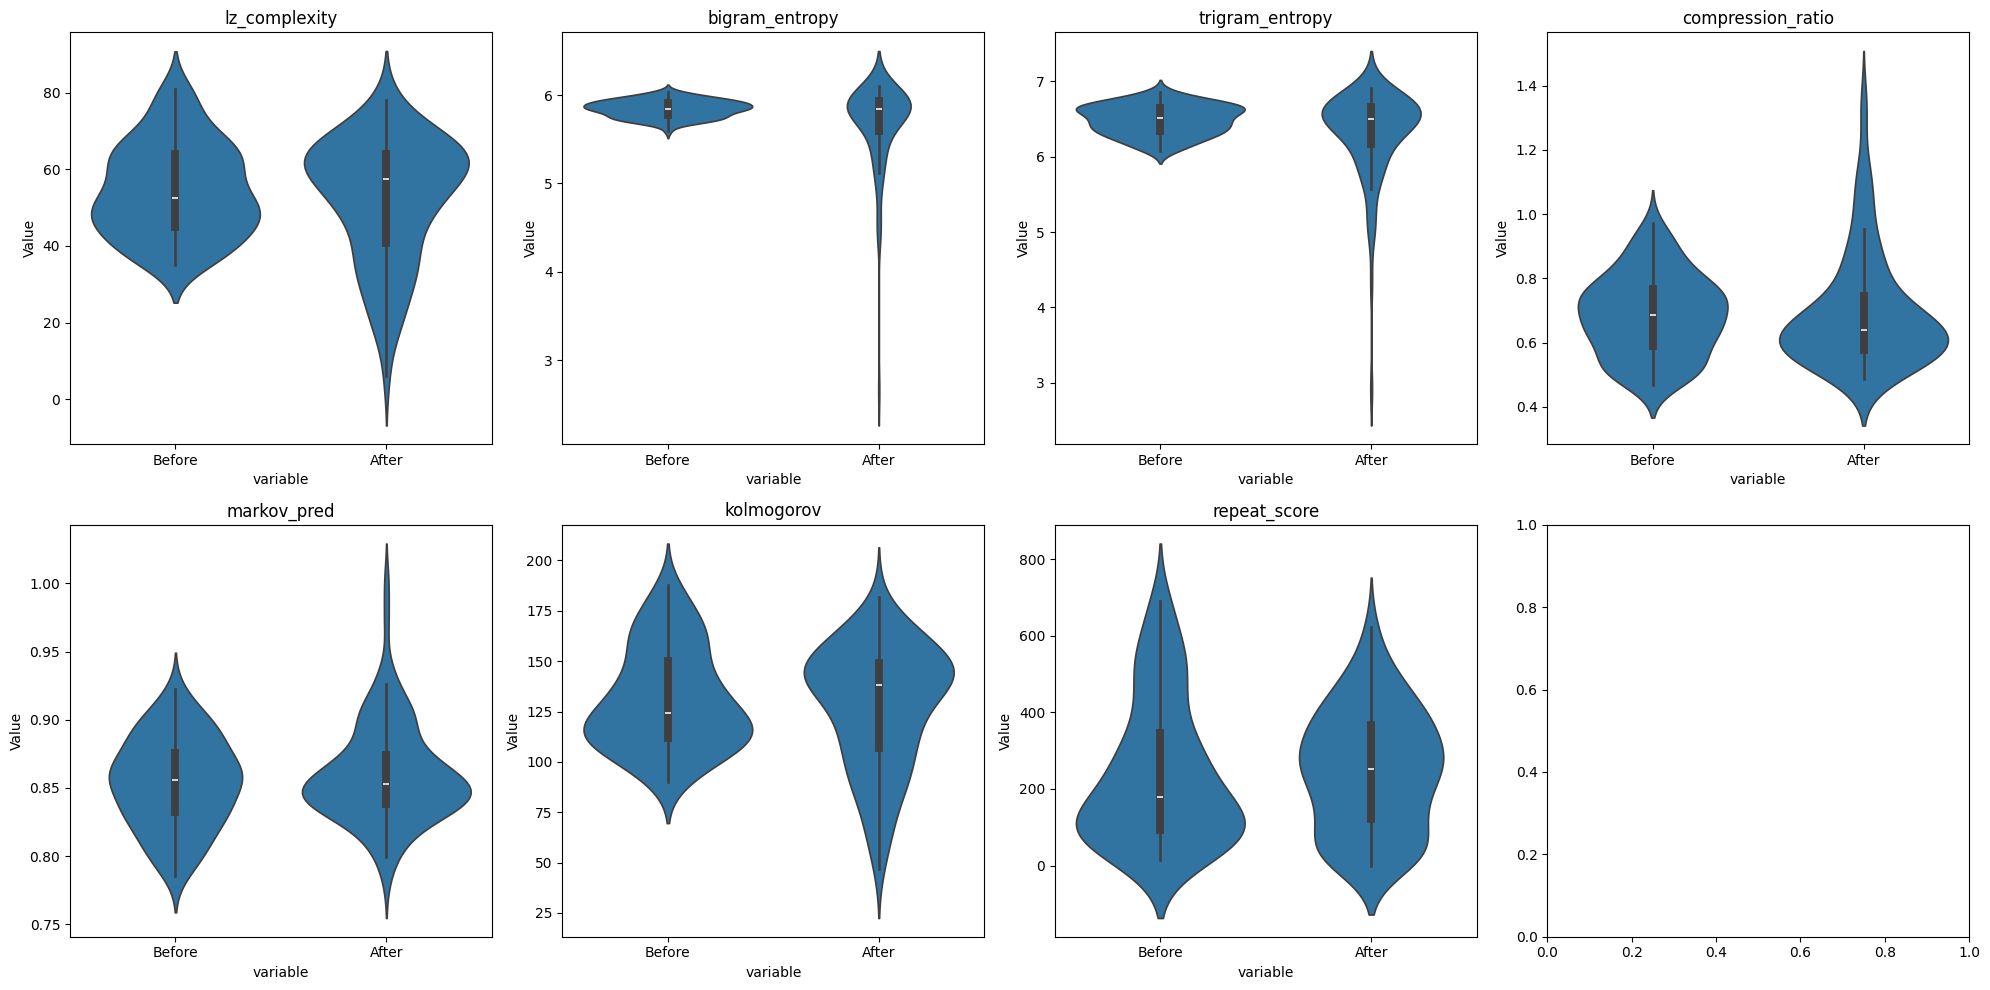


Metric changes by performance quartile:

lz_complexity:
Quartile 1:
  Before: 59.208
  After: 48.500
  Change: -10.708
Quartile 2:
  Before: 58.333
  After: 46.208
  Change: -12.125
Quartile 3:
  Before: 52.375
  After: 55.875
  Change: 3.500
Quartile 4:
  Before: 46.950
  After: 60.100
  Change: 13.150

bigram_entropy:
Quartile 1:
  Before: 5.886
  After: 5.627
  Change: -0.259
Quartile 2:
  Before: 5.860
  After: 5.465
  Change: -0.394
Quartile 3:
  Before: 5.824
  After: 5.757
  Change: -0.067
Quartile 4:
  Before: 5.809
  After: 5.878
  Change: 0.069

trigram_entropy:
Quartile 1:
  Before: 6.579
  After: 6.256
  Change: -0.322
Quartile 2:
  Before: 6.557
  After: 6.035
  Change: -0.523
Quartile 3:
  Before: 6.440
  After: 6.425
  Change: -0.015
Quartile 4:
  Before: 6.368
  After: 6.535
  Change: 0.167

compression_ratio:
Quartile 1:
  Before: 0.637
  After: 0.722
  Change: 0.085
Quartile 2:
  Before: 0.648
  After: 0.779
  Change: 0.132
Quartile 3:
  Before: 0.705
  After: 0.647


In [157]:
# First, let's create a function to split trajectories into before/after
def split_trajectory(traj, split_idx):
    """Split trajectory into before and after segments"""
    if isinstance(split_idx, str) or pd.isna(split_idx):  # Handle DNF cases
        return traj, ""
    return traj[:split_idx], traj[split_idx:]

# Filter out DNF cases
complete_df = explore_df[~explore_df['all_objects_found_idx'].astype(str).str.contains('DNF')]
complete_df = complete_df[~complete_df['all_objects_found_idx'].isna()]

# Add before/after segments to dataframe
complete_df['traj_before'], complete_df['traj_after'] = zip(*complete_df.apply(
    lambda row: split_trajectory(row['extended_explore_traj'], row['all_objects_found_idx']), 
    axis=1
))

# Function to compute all metrics for a trajectory
def compute_predictability_metrics(traj):
    if not traj or len(traj) < 3:  # Handle empty or very short trajectories
        return {
            'lz_complexity': np.nan,
            'bigram_entropy': np.nan,
            'trigram_entropy': np.nan,
            'compression_ratio': np.nan,
            'markov_pred': np.nan,
            'kolmogorov': np.nan,
            'repeat_score': np.nan
        }
    
    return {
        'lz_complexity': lz_complexity(traj),
        'bigram_entropy': ngram_entropy(traj, 2),
        'trigram_entropy': ngram_entropy(traj, 3),
        'compression_ratio': compression_ratio(traj),
        'markov_pred': markov_predictability(traj, order=2),
        'kolmogorov': kolmogorov_complexity(traj),
        'repeat_score': repeat_pattern_score(traj)
    }

# Compute metrics for before and after segments
before_metrics = complete_df['traj_before'].apply(compute_predictability_metrics).apply(pd.Series)
after_metrics = complete_df['traj_after'].apply(compute_predictability_metrics).apply(pd.Series)

# Add prefixes to column names
before_metrics = before_metrics.add_prefix('before_')
after_metrics = after_metrics.add_prefix('after_')

# Combine metrics with original dataframe
analysis_df = pd.concat([complete_df, before_metrics, after_metrics], axis=1)

# Perform statistical tests and create visualizations
metrics = ['lz_complexity', 'bigram_entropy', 'trigram_entropy', 
          'compression_ratio', 'markov_pred', 'kolmogorov', 'repeat_score']

# Statistical tests
print("Statistical tests comparing before vs after metrics:")
for metric in metrics:
    before_vals = analysis_df[f'before_{metric}'].dropna()
    after_vals = analysis_df[f'after_{metric}'].dropna()
    
    # Only include pairs where both before and after are valid
    mask = ~(before_vals.isna() | after_vals.isna())
    before_vals = before_vals[mask]
    after_vals = after_vals[mask]
    
    # Paired t-test
    t_stat, p_val = stats.ttest_rel(before_vals, after_vals)
    print(f"\n{metric}:")
    print(f"Mean before: {before_vals.mean():.3f}")
    print(f"Mean after: {after_vals.mean():.3f}")
    print(f"t-statistic: {t_stat:.3f}")
    print(f"p-value: {p_val:.3f}")

# Visualization
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for i, metric in enumerate(metrics):
    # Create violin plot
    plot_data = pd.DataFrame({
        'Before': analysis_df[f'before_{metric}'],
        'After': analysis_df[f'after_{metric}']
    }).melt()
    
    sns.violinplot(data=plot_data, x='variable', y='value', ax=axes[i])
    axes[i].set_title(metric)
    axes[i].set_ylabel('Value')

plt.tight_layout()
plt.show()

# Additional analysis by performance quartile
print("\nMetric changes by performance quartile:")
for metric in metrics:
    print(f"\n{metric}:")
    for q in range(1, 5):
        q_data = analysis_df[analysis_df['quartile'] == q]
        before_mean = q_data[f'before_{metric}'].mean()
        after_mean = q_data[f'after_{metric}'].mean()
        print(f"Quartile {q}:")
        print(f"  Before: {before_mean:.3f}")
        print(f"  After: {after_mean:.3f}")
        print(f"  Change: {after_mean - before_mean:.3f}")

## Spatial tokenisation

In [237]:
# ... existing imports ...
from collections import defaultdict

def create_ngram_vocabulary(trajectories, min_freq=5):
    # Get most common bigrams and trigrams
    bigrams = Counter([traj[i:i+2] for traj in trajectories for i in range(len(traj)-1)])
    trigrams = Counter([traj[i:i+3] for traj in trajectories for i in range(len(traj)-2)])
    fourgrams = Counter([traj[i:i+4] for traj in trajectories for i in range(len(traj)-3)])
    

    # Filter by minimum frequency
    common_bigrams = {k: v for k, v in bigrams.items() if v >= min_freq}
    common_trigrams = {k: v for k, v in trigrams.items() if v >= min_freq}
    common_fourgrams = {k: v for k, v in fourgrams.items() if v >= min_freq}
    
    # Combine all n-grams and sort by frequency
    all_ngrams = []
    for ngram, freq in common_bigrams.items():
        all_ngrams.append((ngram, freq, 'B'))
    for ngram, freq in common_trigrams.items():
        all_ngrams.append((ngram, freq, 'T'))
    for ngram, freq in common_fourgrams.items():
        all_ngrams.append((ngram, freq, 'F'))
    
    # Sort by frequency (descending)
    all_ngrams.sort(key=lambda x: x[1], reverse=True)
    
    # Create vocabulary mapping
    vocab = {}
    for i, (ngram, freq, type_prefix) in enumerate(all_ngrams):
        vocab[ngram] = f'{type_prefix}{i}'
    
    return vocab
    # # Create vocabulary mapping (trigrams first, then bigrams)
    # vocab = {}
    # for i, (ngram, _) in enumerate(sorted(common_fourgrams.items(), key=lambda x: x[1], reverse=True)):
    #     vocab[ngram] = f'F{i}'  # F0, F1, F2, etc. for fourgrams
    # for i, (ngram, _) in enumerate(sorted(common_trigrams.items(), key=lambda x: x[1], reverse=True)):
    #     vocab[ngram] = f'T{i}'  # T0, T1, T2, etc. for trigrams
    # for i, (ngram, _) in enumerate(sorted(common_bigrams.items(), key=lambda x: x[1], reverse=True)):
    #     vocab[ngram] = f'B{i}'  # B0, B1, B2, etc. for bigrams
        
    # return vocab

def simplify_trajectory(traj, vocab):
    simplified = traj
    # Replace longest n-grams first
    for ngram, token in sorted(vocab.items(), key=lambda x: len(x[0]), reverse=True):
        simplified = simplified.replace(ngram, f' {token} ')
    return ' '.join(simplified.split())  # Clean up extra spaces

# Create vocabulary and simplify trajectories
vocab = create_ngram_vocabulary(explore_df['explore_traj'].values)
explore_df['simplified_traj'] = explore_df['explore_traj'].apply(lambda x: simplify_trajectory(x, vocab))

# Print vocabulary mapping and example
print("Vocabulary Mapping:")
for ngram, token in list(vocab.items())[:10]:  # Show first 10 mappings
    print(f"{token}: {ngram}")

print("\nExample Trajectory Simplification:")
print("Original:", explore_df['explore_traj'].iloc[0][:50], "...")
print("Simplified:", explore_df['simplified_traj'].iloc[0][:50], "...")

Vocabulary Mapping:
B0: TX
B1: XT
B2: HG
B3: XV
B4: VX
B5: GH
B6: UW
B7: WU
T8: UWU
B9: GA

Example Trajectory Simplification:
Original: URQTXVXZPZXTQHGLGAGHBCICDEMOMSRUTXTUWUTXVYVXZPZXTQ ...
Simplified: B33 F189 F29 X F182 L F93 B F171 F131 S F220 F89 T ...


In [238]:
# Split all trajectories into tokens and count them
all_tokens = ' '.join(explore_df['simplified_traj']).split()
token_counts = Counter(all_tokens)

# Print the 10 most common tokens with their counts
print("Most common tokens:")
for token, count in token_counts.most_common(10):
    print(f"{token}: {count} occurrences")

# If you want to see what the original n-grams were for these tokens
print("\nOriginal n-grams for top tokens:")
reverse_vocab = {v: k for k, v in vocab.items()}
for token, count in token_counts.most_common(10):
    if token in reverse_vocab:
        print(f"{token} ({count} occurrences) = {reverse_vocab[token]}")
    else:
        print(f"{token} ({count} occurrences) = single character")

Most common tokens:
F29: 359 occurrences
F32: 357 occurrences
F69: 267 occurrences
F89: 223 occurrences
F108: 203 occurrences
L: 197 occurrences
F117: 166 occurrences
X: 163 occurrences
F140: 158 occurrences
F104: 155 occurrences

Original n-grams for top tokens:
F29 (359 occurrences) = XZPZ
F32 (357 occurrences) = EFNF
F69 (267 occurrences) = HGAG
F89 (223 occurrences) = TUWU
F108 (203 occurrences) = XVYV
L (197 occurrences) = single character
F117 (166 occurrences) = DCIC
X (163 occurrences) = single character
F140 (158 occurrences) = RJKJ
F104 (155 occurrences) = UWUT


In [239]:
salient_node = "F29" # XZPZ "T0" #UWU
etreebs = []
baseline_features = []
qs = []
accs = []
traj_lens = []
sexes = []

trajs = {1: [], 2: [], 3: [], 4: []}
for i, row in explore_df.iterrows():
    path = row["simplified_traj"]
    q = row["quartile"]
    # print(path)
    simplified_path = path.split()
    # print(simplified_path)
    # break
    
    for i in range(len(simplified_path)):
        if salient_node == simplified_path[i]: # in path[i]:# if i%5 == 0:
            if not pd.isna(q): 
                trajs[q].append(simplified_path[i: i+8])
    
    traj_lens.append(len(trajs))


print(trajs)
print([len(trajs[i]) for i in range(1,5)])

print([np.mean([len(x) for x in trajs[t]]) for t in trajs])

{1: [['F29', 'F226', 'B51', 'F32', 'F277', 'F217', 'F93', 'Q'], ['F29', 'T74', 'F89', 'B53', 'F110', 'B323', 'F164', 'F29'], ['F29', 'T74', 'F89', 'T61', 'F32', 'F251', 'F69', 'L'], ['F29', 'X', 'F153', 'R', 'T337', 'F69', 'F300', 'F117'], ['F29', 'F226', 'F116', 'F32', 'F208', 'F98', 'L', 'F93'], ['F29', 'F108', 'F29', 'F235', 'F116', 'B70', 'F104', 'B63'], ['F29', 'F235', 'F116', 'B70', 'F104', 'B63', 'F230', 'F93'], ['F29', 'F235', 'B38', 'F29', 'F176', 'T218', 'F213', 'N'], ['F29', 'F176', 'T218', 'F213', 'N'], ['F29', 'X', 'F89', 'T195', 'F32', 'F214', 'Q', 'F134'], ['F29', 'B1', 'F162', 'N'], ['F29', 'T73', 'F140', 'T188', 'F171', 'F131', 'F309', 'F29'], ['F29', 'F108', 'T97', 'F140', 'B55', 'B379', 'F29', 'F108'], ['F29', 'F108', 'T97', 'F89', 'R', 'F116', 'F32', 'F208'], ['F29', 'X', 'F89', 'B53', 'F140', 'B55', 'F117', 'B'], ['F29', 'F235', 'J', 'F213', 'Q', 'F134', 'B14', 'F89'], ['F29', 'T73', 'F140', 'F117', 'D', 'F32', 'F131', 'F32'], ['F29', 'T97', 'F69', 'F167', 'E', 'F2

In [246]:
salient_node = "F29"
etreebs = []
baseline_features = []
qs = []
accs = []
traj_lens = []
sexes = []

# Initialize trajs dictionary with quartile 0 for random walks
trajs = {0: [], 1: [], 2: [], 3: [], 4: []}

# First generate random walks
graph = create_maze_graph()
n_random_walks = 100  # Adjust this number as needed
random_walk_length = 200  # Adjust this length as needed

# Generate random walks and add to trajs[0]
for _ in range(n_random_walks):
    random_traj = random_walk(graph, start_node='A', n_steps=random_walk_length)
    random_traj_str = ''.join(random_traj)  # Convert list to string
    simplified_random = simplify_trajectory(random_traj_str, vocab)
    simplified_path = simplified_random.split()
    
    # Add to trajs[0] when salient node is found
    for i in range(len(simplified_path)):
        if salient_node == simplified_path[i]:
            trajs[0].append(simplified_path[i: i+8])

# Process real trajectories as before
for i, row in explore_df.iterrows():
    path = row["simplified_traj"]
    q = row["quartile"]
    simplified_path = path.split()
    
    for i in range(len(simplified_path)):
        if salient_node == simplified_path[i]:
            if not pd.isna(q): 
                trajs[q].append(simplified_path[i: i+8])
    
    traj_lens.append(len(trajs))

print("Number of trajectories by quartile (including random walks):")
print([len(trajs[i]) for i in range(0,5)])

print("\nMean trajectory lengths by quartile:")
print([np.mean([len(x) for x in trajs[t]]) for t in trajs])

Number of trajectories by quartile (including random walks):
[0, 93, 93, 90, 81]

Mean trajectory lengths by quartile:
[nan, 7.559139784946237, 7.591397849462366, 7.644444444444445, 7.814814814814815]


[7.559139784946237, 7.591397849462366, 7.644444444444445, 7.814814814814815]
Statistical significance tests (Kruskal-Wallis H-test):

Number of Nodes	--	H-statistic: 5.385; p-value: 0.146

Number of Edges	--	H-statistic: 5.385; p-value: 0.146

Tree Depth	--	H-statistic: 45.551; p-value: 0.000

Average Degree	--	H-statistic: 5.385; p-value: 0.146

Diameter	--	H-statistic: 55.085; p-value: 0.000

Number of Leaves	--	H-statistic: 3.571; p-value: 0.312

Average Path Length	--	H-statistic: 62.003; p-value: 0.000

Average Branching Factor	--	H-statistic: 5.385; p-value: 0.146



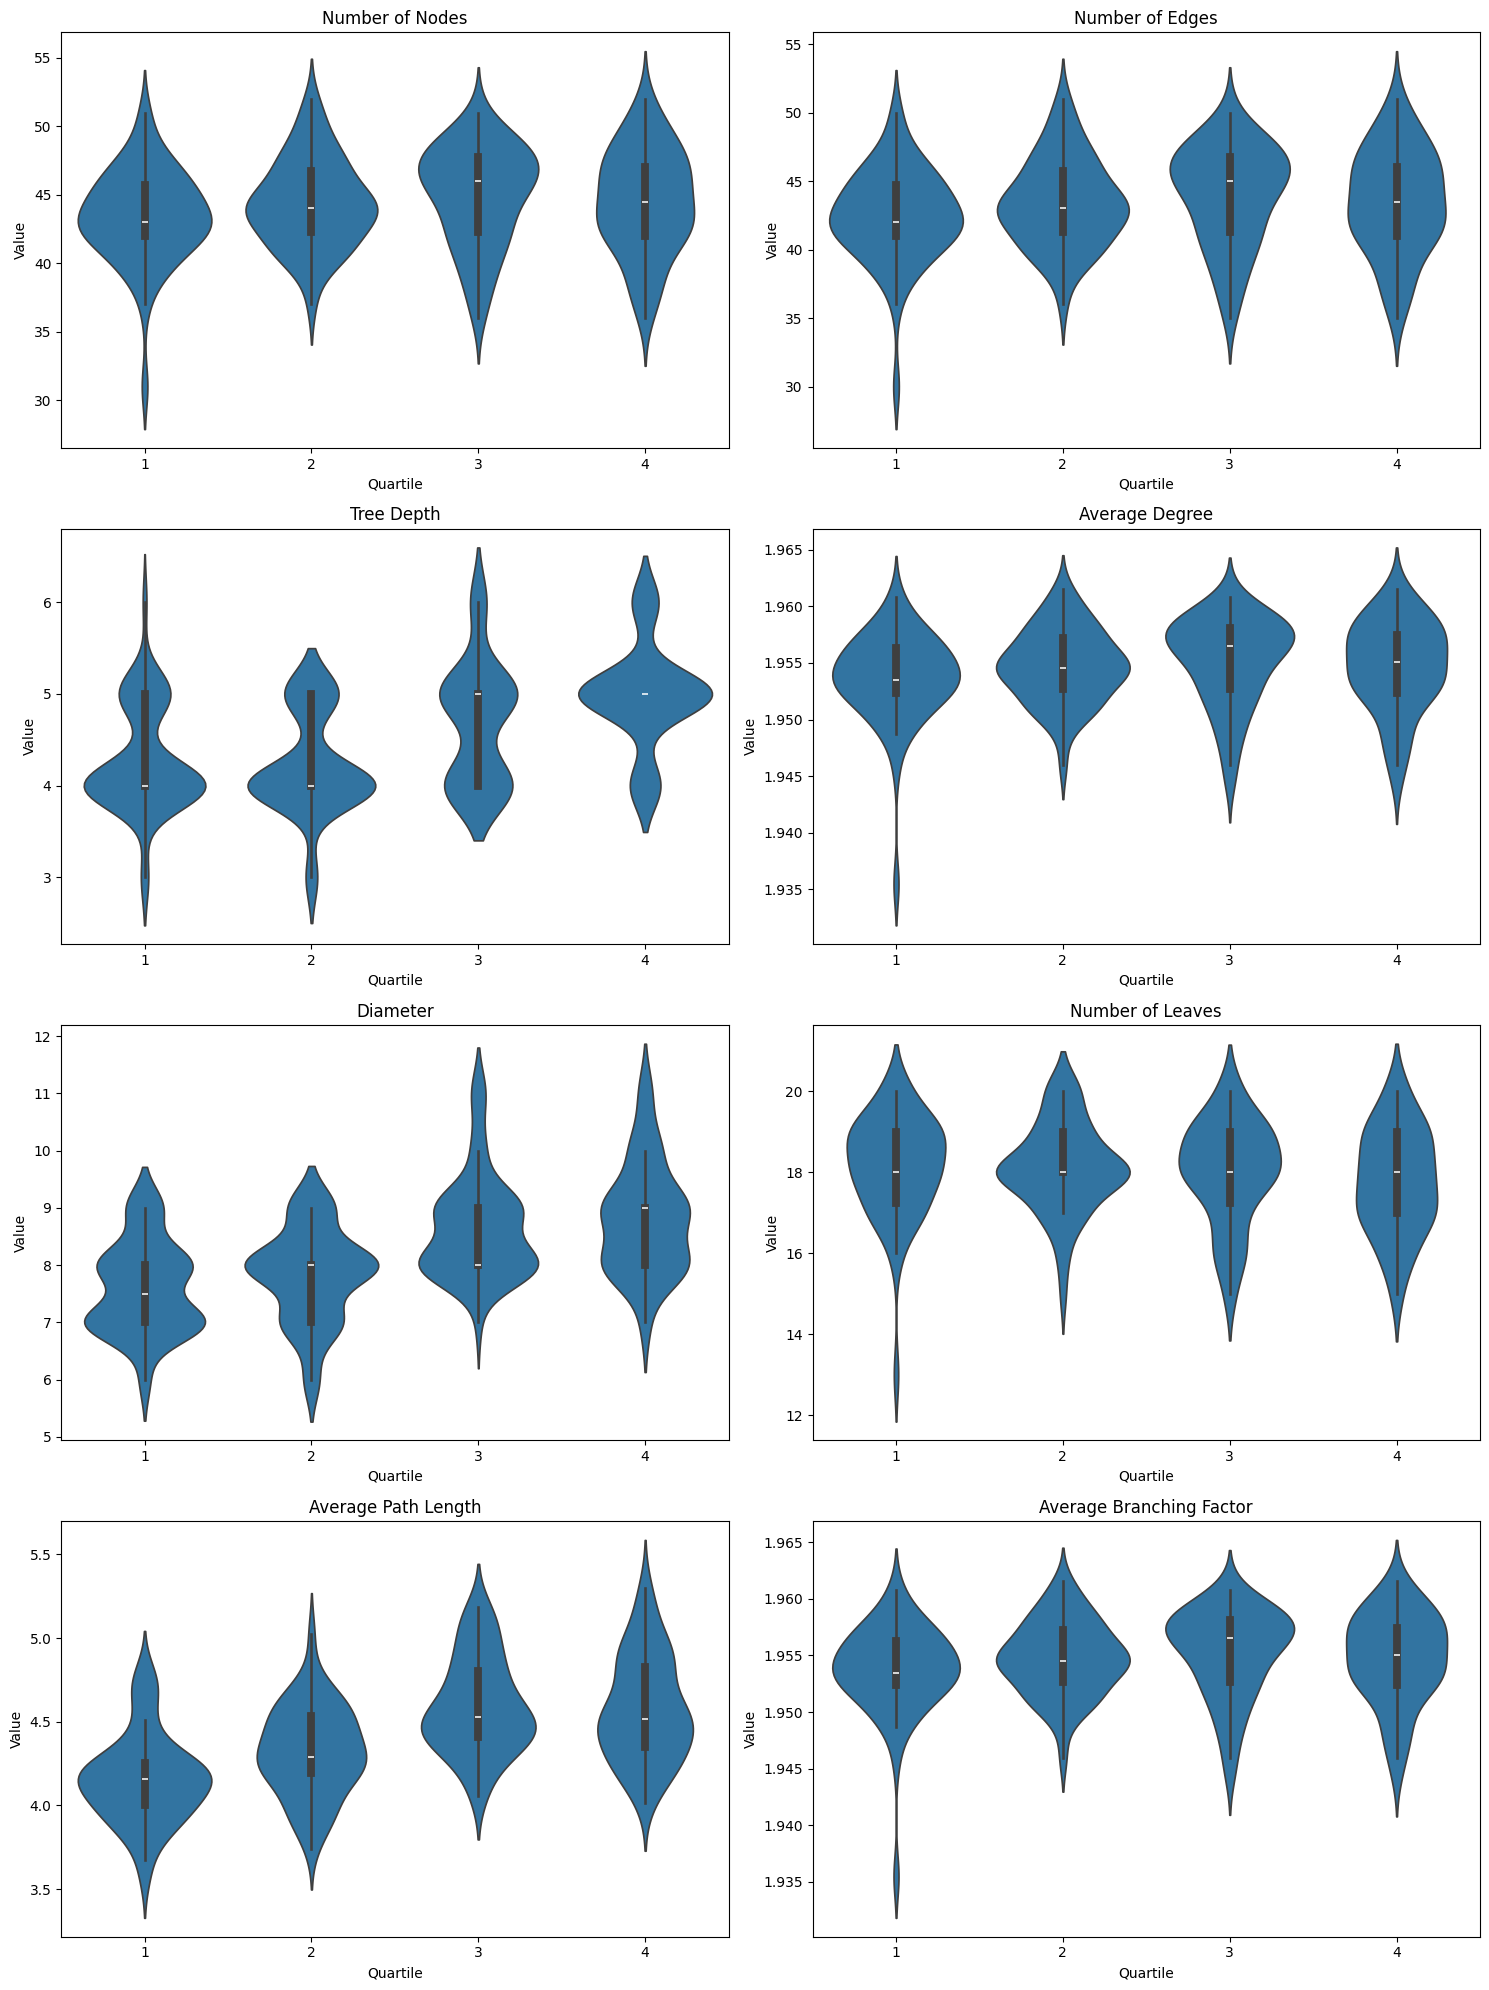

In [240]:
def generate_bootstrap_trees(quartile_trajs, n_bootstraps=100, sample_size=50):
    """Generate multiple trees via bootstrap sampling and extract their features."""
    bootstrap_features = []
    
    for _ in range(n_bootstraps):
        # Sample with replacement
        sampled_trajs = random.choices(quartile_trajs, k=min(sample_size, len(quartile_trajs)))
        
        # Generate tree
        G = nx.Graph()
        G.add_node(salient_node + "_0", color="red", end=False)
        
        visited = {}
        generate_reeb_tree(0, salient_node, sampled_trajs, 
                          [i for i in range(len(sampled_trajs))], 
                          G, visited, SUCCESS="IMPOSSIBLE", DEBUG=False)
        
        # Convert and extract features
        new_G = nx.relabel.convert_node_labels_to_integers(G)
        features = extract_tree_features(new_G, 0)
        bootstrap_features.append(features)
    
    return np.array(bootstrap_features)

print([np.mean([len(x) for x in trajs[t]]) for t in trajs])
# Generate bootstrap samples for each quartile
bootstrap_results = {}
for q in range(1, 5):
    if len(trajs[q]) > 0:
        bootstrap_results[q] = generate_bootstrap_trees(trajs[q], n_bootstraps=50, sample_size=20)

# Statistical testing

# For each feature, perform statistical tests between quartiles
feature_names = [
    'Number of Nodes', 'Number of Edges', 'Tree Depth',
    'Average Degree', 'Diameter', 'Number of Leaves',
    'Average Path Length', 'Average Branching Factor'
]

print("Statistical significance tests (Kruskal-Wallis H-test):\n")
for i, feature in enumerate(feature_names):
    # Extract feature values for each quartile
    feature_by_quartile = [bootstrap_results[q][:, i] for q in range(1, 5) if q in bootstrap_results]
    
    # Perform Kruskal-Wallis H-test
    h_stat, p_val = stats.kruskal(*feature_by_quartile)
    
    print(f"{feature}\t--\tH-statistic: {h_stat:.3f}; p-value: {p_val:.3f}\n")

fig, axs = plt.subplots(4, 2, figsize=(15, 20))
axs = axs.ravel()

for i, feature in enumerate(feature_names):
    data = []
    for q in range(1, 5):
        if q in bootstrap_results:
            feature_vals = bootstrap_results[q][:, i]
            data.extend([(q, val) for val in feature_vals])

    df = pd.DataFrame(data, columns=['Quartile', 'Value'])

    sns.violinplot(data=df, x='Quartile', y='Value', ax=axs[i])
    axs[i].set_title(feature)

plt.tight_layout()
plt.show()


make giant flow tree, colour by quartile, do the subgroups correlate with quartile or with accuracy or with gender or with?

flesh out hypothesis testing w other actual hypotheses

In [241]:
for i, feature in enumerate(feature_names):
    feature_by_quartile = [bootstrap_results[q][:, i] for q in range(1, 5) if q in bootstrap_results]
    
    # ANOVA
    f_stat, p_val_anova = stats.f_oneway(*feature_by_quartile)
    
    # Kruskal-Wallis
    h_stat, p_val_kw = stats.kruskal(*feature_by_quartile)
    
    print(f"\n{feature}:")
    print(f"ANOVA - F-statistic: {f_stat:.3f}, p-value: {p_val_anova:.3f}")
    print(f"K-W   - H-statistic: {h_stat:.3f}, p-value: {p_val_kw:.3f}")

    # If significant differences found, you might want to do post-hoc tests
    if p_val_kw < 0.05:
        # Perform pairwise Mann-Whitney U tests with Bonferroni correction
        from itertools import combinations
        sig_pairs = []
        for q1, q2 in combinations(range(len(feature_by_quartile)), 2):
            stat, p = stats.mannwhitneyu(feature_by_quartile[q1], feature_by_quartile[q2])
            if p < 0.05:
                sig_pairs.append(f"({q1+1}, {q2+1})")
        print("\nSignificant pairwise comparisons (Mann-Whitney U):" + " ".join(sig_pairs))  # Bonferroni correction (*6 for 6 comparisons)


Number of Nodes:
ANOVA - F-statistic: 1.532, p-value: 0.207
K-W   - H-statistic: 5.385, p-value: 0.146

Number of Edges:
ANOVA - F-statistic: 1.532, p-value: 0.207
K-W   - H-statistic: 5.385, p-value: 0.146

Tree Depth:
ANOVA - F-statistic: 18.818, p-value: 0.000
K-W   - H-statistic: 45.551, p-value: 0.000

Significant pairwise comparisons (Mann-Whitney U):(1, 3) (1, 4) (2, 3) (2, 4) (3, 4)

Average Degree:
ANOVA - F-statistic: 1.395, p-value: 0.246
K-W   - H-statistic: 5.385, p-value: 0.146

Diameter:
ANOVA - F-statistic: 24.165, p-value: 0.000
K-W   - H-statistic: 55.085, p-value: 0.000

Significant pairwise comparisons (Mann-Whitney U):(1, 3) (1, 4) (2, 3) (2, 4)

Number of Leaves:
ANOVA - F-statistic: 1.076, p-value: 0.360
K-W   - H-statistic: 3.571, p-value: 0.312

Average Path Length:
ANOVA - F-statistic: 27.811, p-value: 0.000
K-W   - H-statistic: 62.003, p-value: 0.000

Significant pairwise comparisons (Mann-Whitney U):(1, 2) (1, 3) (1, 4) (2, 3) (2, 4)

Average Branching Fact

## Try spatial with before / after

In [243]:
# First, let's create a function to split trajectories into before/after
def split_trajectory(traj, split_idx):
    """Split trajectory into before and after segments"""
    if isinstance(split_idx, str) or pd.isna(split_idx):  # Handle DNF cases
        return traj, ""

    return "".join(collapse_traj(traj[:split_idx])), "".join(collapse_traj(traj[split_idx:]))

# Filter out DNF cases
complete_df = explore_df[~explore_df['all_objects_found_idx'].astype(str).str.contains('DNF')]
complete_df = complete_df[~complete_df['all_objects_found_idx'].isna()]

# Add before/after segments to dataframe
complete_df['traj_before'], complete_df['traj_after'] = zip(*complete_df.apply(
    lambda row: split_trajectory(row['extended_explore_traj'], row['all_objects_found_idx']), 
    axis=1
))

vocab = create_ngram_vocabulary(complete_df['traj_before'].values + complete_df['traj_after'].values)
complete_df['simplified_before_traj'] = complete_df['traj_before'].apply(lambda x: simplify_trajectory(x, vocab))
complete_df['simplified_after_traj'] = complete_df['traj_after'].apply(lambda x: simplify_trajectory(x, vocab))

# Split all trajectories into tokens and count them
all_tokens = ' '.join(complete_df['simplified_before_traj']).split() + ' '.join(complete_df['simplified_after_traj']).split()
token_counts = Counter(all_tokens)

# Print the 10 most common tokens with their counts
print("Most common tokens:")
for token, count in token_counts.most_common(10):
    print(f"{token}: {count} occurrences")

# If you want to see what the original n-grams were for these tokens
print("\nOriginal n-grams for top tokens:")
reverse_vocab = {v: k for k, v in vocab.items()}
for token, count in token_counts.most_common(10):
    if token in reverse_vocab:
        print(f"{token} ({count} occurrences) = {reverse_vocab[token]}")
    else:
        print(f"{token} ({count} occurrences) = single character")
   

Most common tokens:
F25: 311 occurrences
F33: 304 occurrences
F71: 226 occurrences
F93: 187 occurrences
L: 186 occurrences
F97: 184 occurrences
X: 140 occurrences
F134: 137 occurrences
F115: 136 occurrences
F109: 129 occurrences

Original n-grams for top tokens:
F25 (311 occurrences) = EFNF
F33 (304 occurrences) = XZPZ
F71 (226 occurrences) = HGAG
F93 (187 occurrences) = XVYV
L (186 occurrences) = single character
F97 (184 occurrences) = TUWU
X (140 occurrences) = single character
F134 (137 occurrences) = RJKJ
F115 (136 occurrences) = DCIC
F109 (129 occurrences) = UWUT


In [244]:
salient_node = "F25" # EFNF

trajs = {"B": {1: [], 2: [], 3: [], 4: []}, "A": {1: [], 2: [], 3: [], 4: []}}
for i, row in complete_df.iterrows():
    bpath = row["simplified_before_traj"].split()
    apath = row["simplified_after_traj"].split()

    q = row["quartile"]

    for i in range(len(bpath)):
        if salient_node == bpath[i]: # in path[i]:# if i%5 == 0:
            if not pd.isna(q): 
                trajs["B"][q].append(bpath[i: i+8])

    for i in range(len(apath)):
        if salient_node == apath[i]: # in path[i]:# if i%5 == 0:
            if not pd.isna(q): 
                trajs["A"][q].append(apath[i: i+8])
                
                
print(trajs)
print([len(trajs["A"][i]) for i in range(1,5)])
print([len(trajs["B"][i]) for i in range(1,5)])

print([np.mean([len(x) for x in trajs["A"][t]]) for t in trajs["A"]])
print([np.mean([len(x) for x in trajs["B"][t]]) for t in trajs["B"]])

{'B': {1: [['F25', 'F281', 'F208', 'F99', 'Q', 'F149', 'F212', 'F134'], ['F25', 'F259', 'F71', 'L', 'F158', 'F33', 'X', 'F162'], ['F25', 'E', 'F115', 'B', 'F71', 'L', 'F158', 'B12'], ['F25', 'F281', 'F109', 'B3', 'F33', 'F222', 'F117', 'F25'], ['F25', 'F213', 'F105', 'L', 'F99', 'F185', 'B320', 'F294'], ['F25', 'F215', 'Q', 'F149', 'B53', 'F179', 'F136', 'F25'], ['F25', 'T200'], ['F25', 'E', 'F115', 'B', 'F71', 'F175', 'R', 'F117'], ['F25', 'E', 'F115', 'F297', 'F124', '#', 'F287', 'F25'], ['F25', 'E', 'F115', 'T186'], ['F25', 'F281', 'B48', 'F93', 'F222', 'F109', 'T82', 'F97'], ['F25', 'F136', 'T245', 'F71', 'L', 'F158', 'B328', 'F86'], ['F25', 'F136', 'B68', 'F109', 'F205'], ['F25', 'E', 'F160', 'F115', 'B', 'F71', 'H', 'F305'], ['F25', 'B60', 'F105', 'L', 'F99', 'B48', 'F33', 'B3'], ['F25', 'F213', 'F105', 'L', 'F99', 'B48', 'F93', 'F33'], ['F25', 'E', 'F115', 'B', 'F71', 'L', 'F158', 'F93'], ['F25', 'F215', 'F109', 'B3', 'F33', 'T82', 'F97', 'F134'], ['F25', 'F281', 'F109', 'B62', 

Statistical significance tests (Mann-Whitney U-test):

Number of Nodes:
U-statistic: 4261.500
p-value: 0.071

Number of Edges:
U-statistic: 4261.500
p-value: 0.071

Tree Depth:
U-statistic: 5110.000
p-value: 0.758

Average Degree:
U-statistic: 4261.500
p-value: 0.071

Diameter:
U-statistic: 5509.500
p-value: 0.188

Number of Leaves:
U-statistic: 3467.500
p-value: 0.000

Average Path Length:
U-statistic: 7153.000
p-value: 0.000

Average Branching Factor:
U-statistic: 4261.500
p-value: 0.071



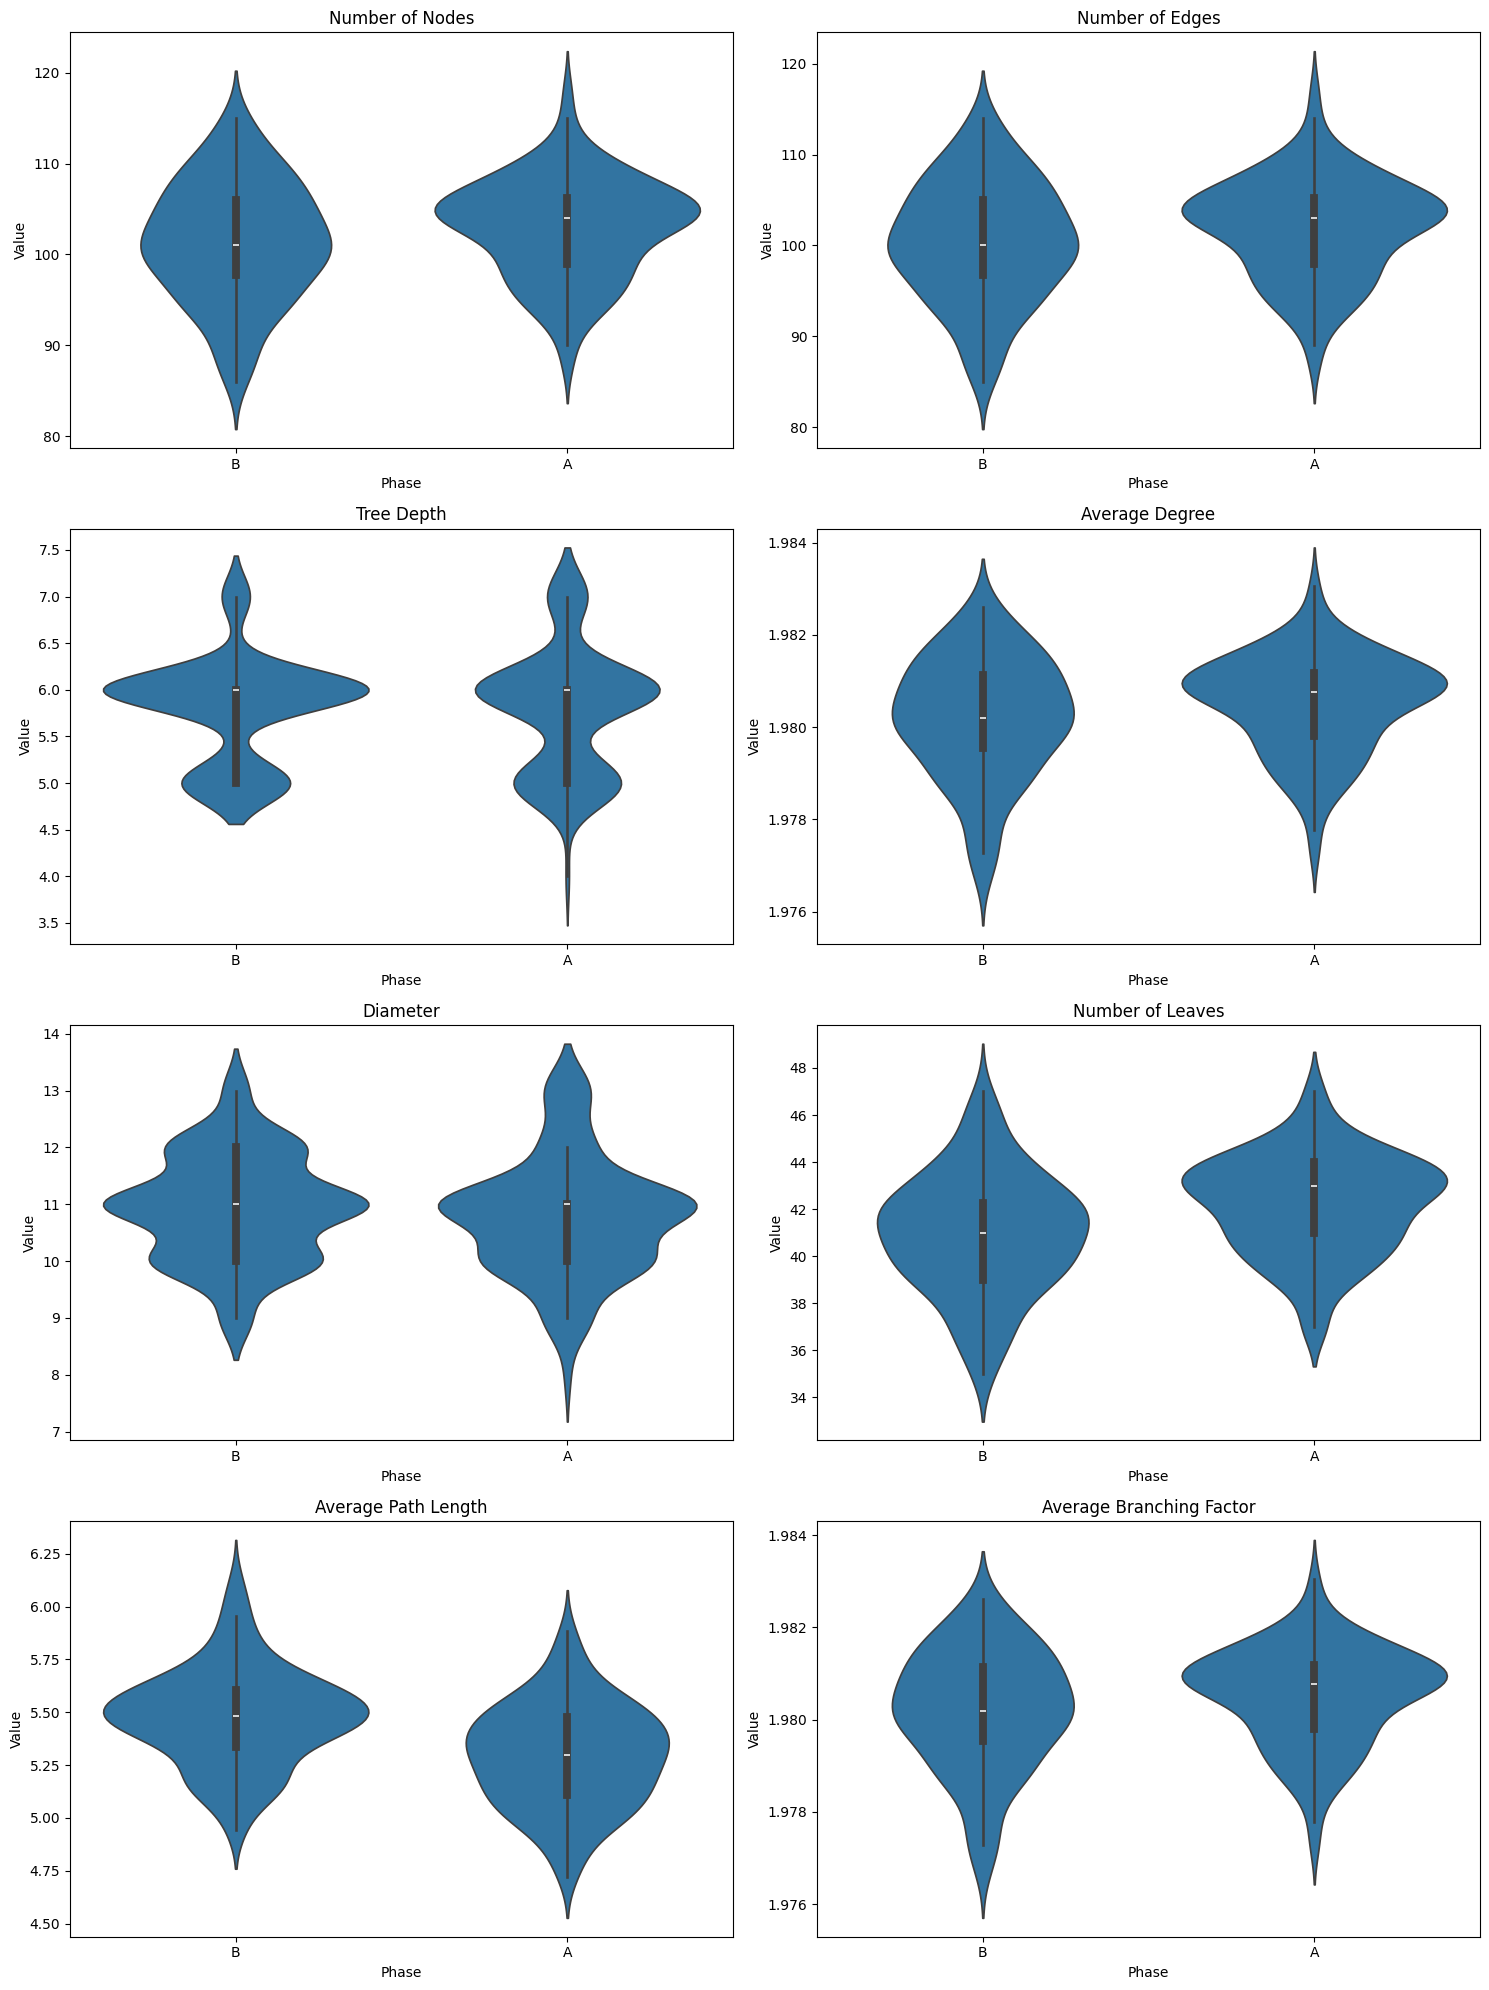

In [245]:
# Generate bootstrap samples for Before and After groups
bootstrap_results = {
    "B": generate_bootstrap_trees(trajs["B"][1] + trajs["B"][2] + trajs["B"][3] + trajs["B"][4]),
    "A": generate_bootstrap_trees(trajs["A"][1] + trajs["A"][2] + trajs["A"][3] + trajs["A"][4])
}

# Statistical testing
print("Statistical significance tests (Mann-Whitney U-test):\n")
for i, feature in enumerate(feature_names):
    # Extract feature values for Before and After
    before_vals = bootstrap_results["B"][:, i]
    after_vals = bootstrap_results["A"][:, i]
    
    # Perform Mann-Whitney U-test
    stat, p_val = stats.mannwhitneyu(before_vals, after_vals)
    
    print(f"{feature}:")
    print(f"U-statistic: {stat:.3f}")
    print(f"p-value: {p_val:.3f}\n")

# Plotting distributions of features
fig, axs = plt.subplots(4, 2, figsize=(15, 20))
axs = axs.ravel()

for i, feature in enumerate(feature_names):
    data = []
    for phase in ["B", "A"]:
        feature_vals = bootstrap_results[phase][:, i]
        data.extend([(phase, val) for val in feature_vals])

    df = pd.DataFrame(data, columns=['Phase', 'Value'])

    sns.violinplot(data=df, x='Phase', y='Value', ax=axs[i])
    axs[i].set_title(feature)

plt.tight_layout()
plt.show()

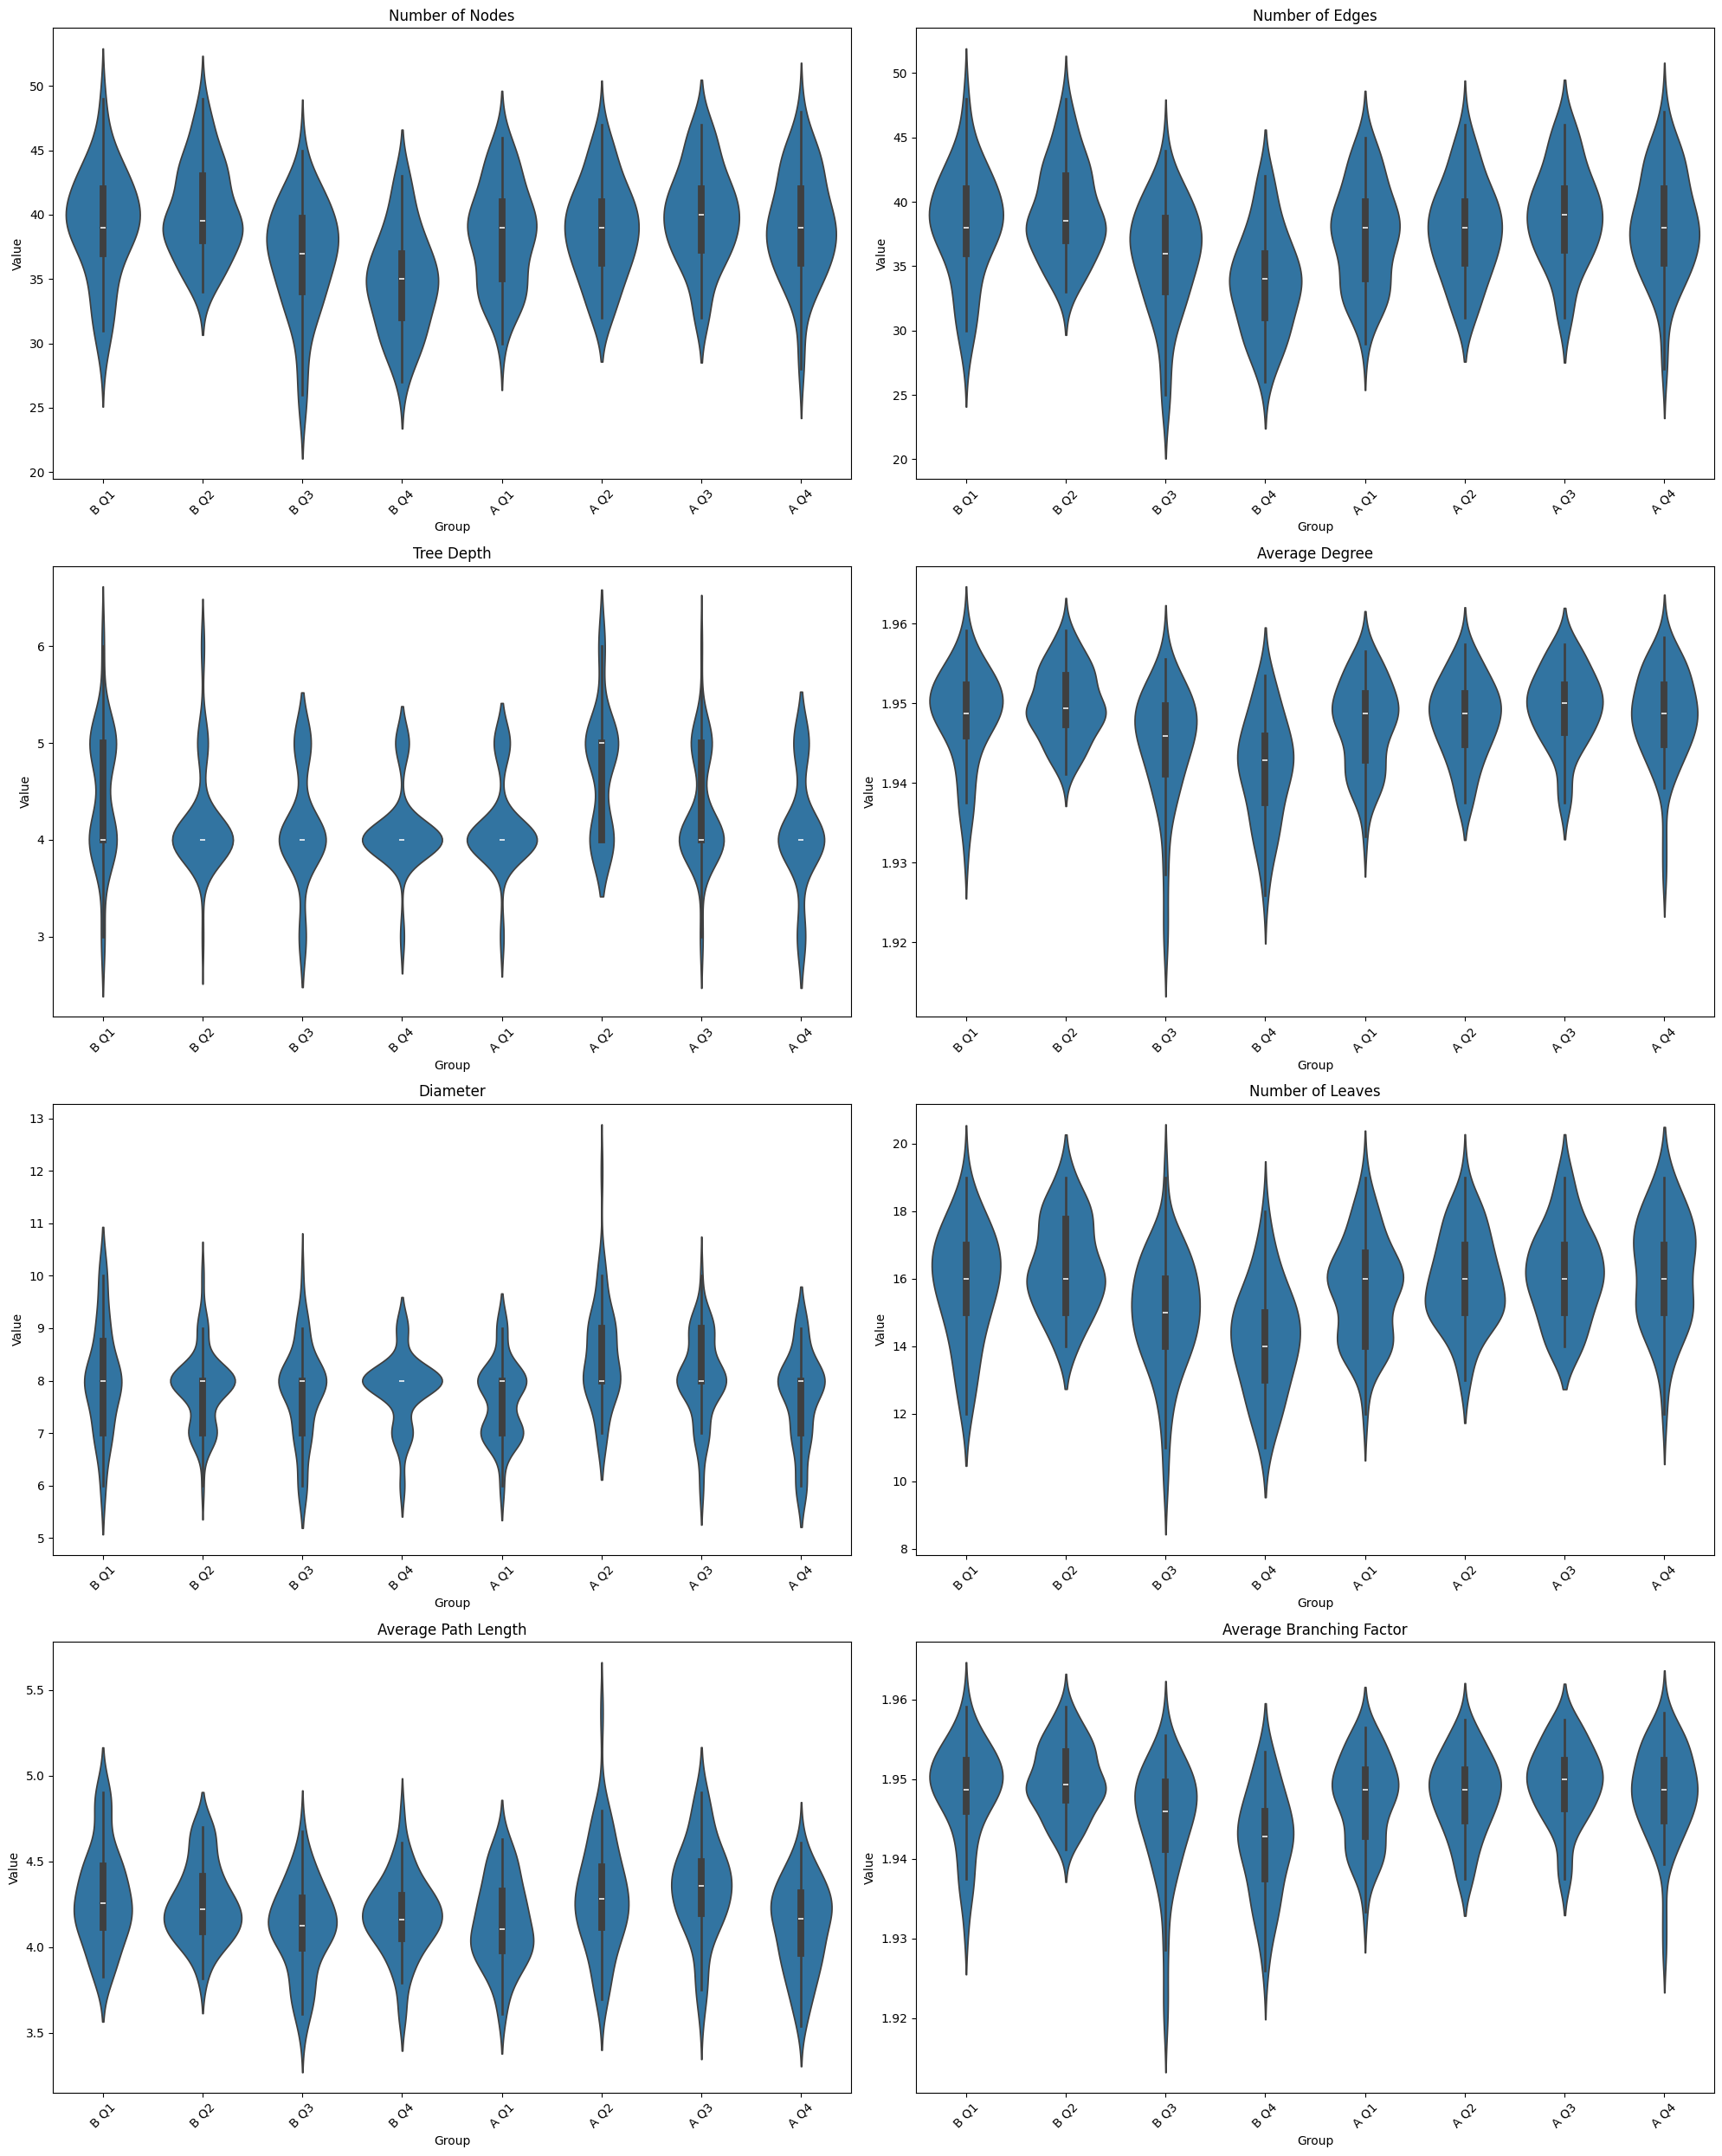


Statistical Tests (Kruskal-Wallis):
--------------------------------------------------

Number of Nodes:
Q1 Before vs After: H=1.084, p=0.298
Q2 Before vs After: H=2.702, p=0.100
Q3 Before vs After: H=12.418, p=0.000
Q4 Before vs After: H=23.004, p=0.000
B Quartile Comparison: H=43.394, p=0.000
A Quartile Comparison: H=3.894, p=0.273

Number of Edges:
Q1 Before vs After: H=1.084, p=0.298
Q2 Before vs After: H=2.702, p=0.100
Q3 Before vs After: H=12.418, p=0.000
Q4 Before vs After: H=23.004, p=0.000
B Quartile Comparison: H=43.394, p=0.000
A Quartile Comparison: H=3.894, p=0.273

Tree Depth:
Q1 Before vs After: H=7.887, p=0.005
Q2 Before vs After: H=19.025, p=0.000
Q3 Before vs After: H=1.577, p=0.209
Q4 Before vs After: H=0.008, p=0.928
B Quartile Comparison: H=13.061, p=0.005
A Quartile Comparison: H=30.198, p=0.000

Average Degree:
Q1 Before vs After: H=1.084, p=0.298
Q2 Before vs After: H=2.702, p=0.100
Q3 Before vs After: H=12.418, p=0.000
Q4 Before vs After: H=23.004, p=0.000
B Q

In [235]:
# Generate bootstrap samples for each quartile and phase
bootstrap_results = {
    "B": {},
    "A": {}
}

for phase in ["B", "A"]:
    for q in range(1, 5):
        if len(trajs[phase][q]) > 0:
            bootstrap_results[phase][q] = generate_bootstrap_trees(trajs[phase][q], n_bootstraps=50, sample_size=20)

# Statistical testing and visualization
feature_names = [
    'Number of Nodes', 'Number of Edges', 'Tree Depth',
    'Average Degree', 'Diameter', 'Number of Leaves',
    'Average Path Length', 'Average Branching Factor'
]

# Create figure with subplots for each feature
fig, axs = plt.subplots(4, 2, figsize=(20, 25))
axs = axs.ravel()

for i, feature in enumerate(feature_names):
    data = []
    
    # Collect data for both before and after phases
    for phase in ["B", "A"]:
        for q in range(1, 5):
            if q in bootstrap_results[phase]:
                feature_vals = bootstrap_results[phase][q][:, i]
                data.extend([(f"{phase.capitalize()} Q{q}", val) for val in feature_vals])
    
    # Create DataFrame and plot
    df = pd.DataFrame(data, columns=['Group', 'Value'])
    sns.violinplot(data=df, x='Group', y='Value', ax=axs[i])
    axs[i].set_title(feature)
    axs[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Statistical tests
print("\nStatistical Tests (Kruskal-Wallis):")
print("-" * 50)

for i, feature in enumerate(feature_names):
    print(f"\n{feature}:")
    
    # Test before vs after for each quartile
    for q in range(1, 5):
        if q in bootstrap_results["B"] and q in bootstrap_results["A"]:
            before_vals = bootstrap_results["B"][q][:, i]
            after_vals = bootstrap_results["A"][q][:, i]
            
            stat, p_val = stats.kruskal(before_vals, after_vals)
            print(f"Q{q} Before vs After: H={stat:.3f}, p={p_val:.3f}")
    
    # Test between quartiles for each phase
    for phase in ["B", "A"]:
        feature_by_quartile = [bootstrap_results[phase][q][:, i] 
                             for q in range(1, 5) 
                             if q in bootstrap_results[phase]]
        
        if len(feature_by_quartile) > 1:  # Need at least 2 groups for comparison
            stat, p_val = stats.kruskal(*feature_by_quartile)
            print(f"{phase.capitalize()} Quartile Comparison: H={stat:.3f}, p={p_val:.3f}")

In [ ]:
# Generate bootstrap samples for each quartile
bootstrap_results = {}
for ba in ["B", "A"]:
    for q in range(1, 5):
        if len(trajs[ba][q]) > 0:
            bootstrap_results[ba][q] = generate_bootstrap_trees(trajs[ba][q])

# Statistical testing

# For each feature, perform statistical tests between quartiles
feature_names = [
    'Number of Nodes', 'Number of Edges', 'Tree Depth',
    'Average Degree', 'Diameter', 'Number of Leaves',
    'Average Path Length', 'Average Branching Factor'
]

print("Statistical significance tests (Kruskal-Wallis H-test):\n")
for i, feature in enumerate(feature_names):
    # Extract feature values for each quartile
    feature_by_quartile = [bootstrap_results[q][:, i] for q in range(1, 5) if q in bootstrap_results]
    
    # Perform Kruskal-Wallis H-test
    h_stat, p_val = stats.kruskal(*feature_by_quartile)
    
    print(f"{feature}\t--\tH-statistic: {h_stat:.3f}; p-value: {p_val:.3f}\n")

fig, axs = plt.subplots(4, 2, figsize=(15, 20))
axs = axs.ravel()

for i, feature in enumerate(feature_names):
    data = []
    for q in range(1, 5):
        if q in bootstrap_results:
            feature_vals = bootstrap_results[q][:, i]
            data.extend([(q, val) for val in feature_vals])

    df = pd.DataFrame(data, columns=['Quartile', 'Value'])

    sns.violinplot(data=df, x='Quartile', y='Value', ax=axs[i])
    axs[i].set_title(feature)

plt.tight_layout()
plt.show()



## Try spatial with BPE

In [93]:
def get_stats(vocab):
    """Get counts of all adjacent symbol pairs."""
    pairs = {}
    for word, freq in vocab.items():
        symbols = word.split()
        for i in range(len(symbols)-1):
            pair = (symbols[i], symbols[i+1])
            pairs[pair] = pairs.get(pair, 0) + freq
    return pairs

def merge_vocab(pair, vocab_in):
    """Merge all occurrences of a symbol pair into a single symbol."""
    vocab_out = {}
    bigram = ' '.join(pair)
    replacement = ''.join(pair)
    
    for word, freq in vocab_in.items():
        new_word = word.replace(bigram, replacement)
        vocab_out[new_word] = freq
    
    return vocab_out

def learn_bpe(trajectories, num_merges=50):
    """Learn BPE tokenization from trajectories."""
    # Initialize vocabulary with character-level splits and frequencies
    vocab = Counter(' '.join(char for char in traj) for traj in trajectories)
    
    # Store merge operations
    merges = []
    
    for i in range(num_merges):
        pairs = get_stats(vocab)
        if not pairs:
            break
            
        # Find most frequent pair
        best_pair = max(pairs.items(), key=lambda x: x[1])[0]
        merges.append(best_pair)
        
        # Merge pair in vocabulary
        vocab = merge_vocab(best_pair, vocab)
        
        if i % 10 == 0:
            print(f"Merge {i}: {best_pair} -> {''.join(best_pair)}")
    
    return merges, vocab

def apply_bpe(trajectory, merges):
    """Apply learned BPE merges to new trajectory."""
    word = ' '.join(char for char in trajectory)
    
    for pair in merges:
        bigram = ' '.join(pair)
        replacement = ''.join(pair)
        word = word.replace(bigram, replacement)
    
    return word

# Learn BPE on training data
merges, vocab = learn_bpe(explore_df['explore_traj'].values, num_merges=100)

# Apply BPE to trajectories
explore_df['bpe_traj'] = explore_df['explore_traj'].apply(lambda x: apply_bpe(x, merges))

# Print example results
print("\nExample BPE tokenization:")
print("Original:", explore_df['explore_traj'].iloc[0][:50], "...")
print("BPE tokenized:", explore_df['bpe_traj'].iloc[0][:50], "...")

# Print most common tokens
print("\nMost common tokens after BPE:")
all_tokens = ' '.join(explore_df['bpe_traj']).split()
token_counts = Counter(all_tokens)
for token, count in token_counts.most_common(10):
    print(f"{token}: {count} occurrences")

Merge 0: ('T', 'X') -> TX
Merge 10: ('Z', 'P') -> ZP
Merge 20: ('B', 'C') -> BC
Merge 30: ('R', 'UWU') -> RUWU
Merge 40: ('DCIC', 'B') -> DCICB
Merge 50: ('D', 'J') -> DJ
Merge 60: ('RSM', 'EFNFE') -> RSMEFNFE
Merge 70: ('DEFNFE', 'MS') -> DEFNFEMS
Merge 80: ('TXVYV', 'XZPZXTQ') -> TXVYVXZPZXTQ
Merge 90: ('B', 'HQ') -> BHQ

Example BPE tokenization:
Original: URQTXVXZPZXTQHGLGAGHBCICDEMOMSRUTXTUWUTXVYVXZPZXTQ ...
BPE tokenized: U RQTXV XZPZXTQ HGLGAGHBCIC DEMOMS RU TXTUWU TXVYV ...

Most common tokens after BPE:
RJKJ: 165 occurrences
RQ: 149 occurrences
N: 99 occurrences
DJKJ: 95 occurrences
RJ: 94 occurrences
XTQ: 76 occurrences
RSMOMEFNFE: 67 occurrences
RU: 60 occurrences
DCICB: 60 occurrences
TQ: 58 occurrences


In [95]:
salient_node = "RJKJ" # XZPZ "T0" #UWU
etreebs = []
baseline_features = []
qs = []
accs = []
traj_lens = []
sexes = []

bpe_trajs = {1: [], 2: [], 3: [], 4: []}
for i, row in explore_df.iterrows():
    path = row["bpe_traj"]
    q = row["quartile"]
    # print(path)
    simplified_path = path.split()
    # print(simplified_path)
    # break
    
    for i in range(len(simplified_path)):
        if salient_node == simplified_path[i]: # in path[i]:# if i%5 == 0:
            if not pd.isna(q): 
                bpe_trajs[q].append(simplified_path[i: i+10])
    
    traj_lens.append(len(trajs))
    # trajs = trajs[:25]

Statistical significance tests (Kruskal-Wallis H-test):

Number of Nodes:
H-statistic: 238.749
p-value: 0.000

Number of Edges:
H-statistic: 238.749
p-value: 0.000

Tree Depth:
H-statistic: 77.876
p-value: 0.000

Average Degree:
H-statistic: 238.749
p-value: 0.000

Diameter:
H-statistic: 91.151
p-value: 0.000

Number of Leaves:
H-statistic: 204.916
p-value: 0.000

Average Path Length:
H-statistic: 227.565
p-value: 0.000

Average Branching Factor:
H-statistic: 238.749
p-value: 0.000



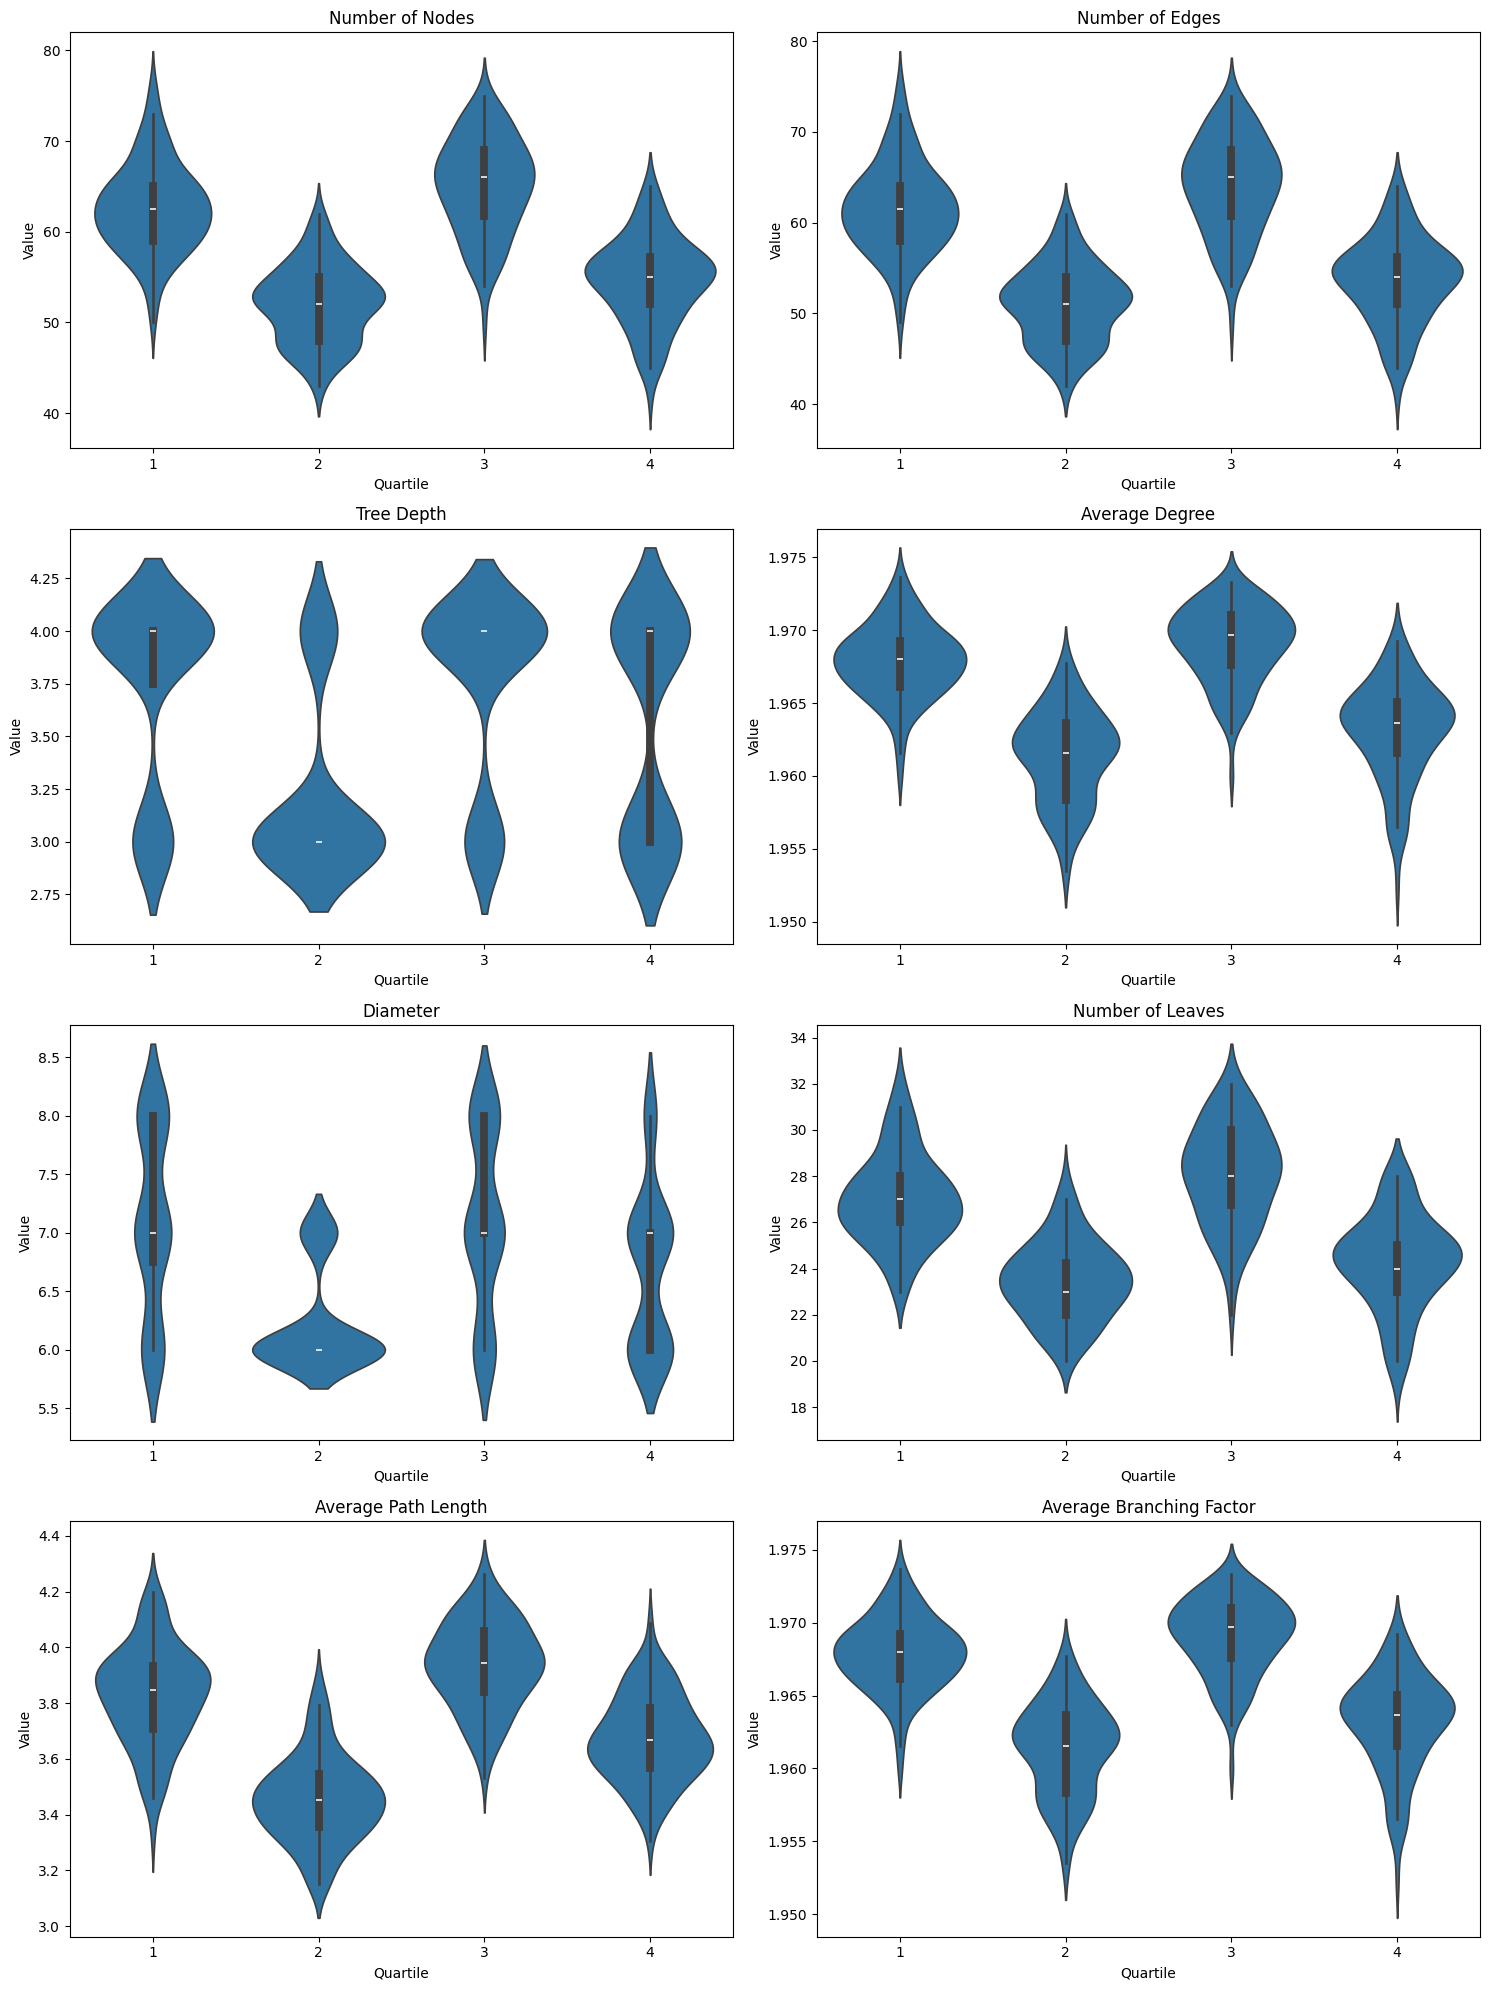

In [96]:
def generate_bootstrap_trees(quartile_trajs, n_bootstraps=100, sample_size=50):
    """Generate multiple trees via bootstrap sampling and extract their features."""
    bootstrap_features = []
    
    for _ in range(n_bootstraps):
        # Sample with replacement
        sampled_trajs = random.choices(quartile_trajs, k=min(sample_size, len(quartile_trajs)))
        
        # Generate tree
        G = nx.Graph()
        G.add_node(salient_node + "_0", color="red", end=False)
        
        visited = {}
        generate_reeb_tree(0, salient_node, sampled_trajs, 
                          [i for i in range(len(sampled_trajs))], 
                          G, visited, SUCCESS="IMPOSSIBLE", DEBUG=False)
        
        # Convert and extract features
        new_G = nx.relabel.convert_node_labels_to_integers(G)
        features = extract_tree_features(new_G, 0)
        bootstrap_features.append(features)
    
    return np.array(bootstrap_features)

# Generate bootstrap samples for each quartile
bootstrap_results = {}
for q in range(1, 5):
    if len(bpe_trajs[q]) > 0:
        bootstrap_results[q] = generate_bootstrap_trees(bpe_trajs[q])

# Statistical testing
# For each feature, perform statistical tests between quartiles
feature_names = [
    'Number of Nodes', 'Number of Edges', 'Tree Depth',
    'Average Degree', 'Diameter', 'Number of Leaves',
    'Average Path Length', 'Average Branching Factor'
]

print("Statistical significance tests (Kruskal-Wallis H-test):\n")
for i, feature in enumerate(feature_names):
    # Extract feature values for each quartile
    feature_by_quartile = [bootstrap_results[q][:, i] for q in range(1, 5) if q in bootstrap_results]
    
    # Perform Kruskal-Wallis H-test
    h_stat, p_val = stats.kruskal(*feature_by_quartile)
    
    print(f"{feature}:")
    print(f"H-statistic: {h_stat:.3f}")
    print(f"p-value: {p_val:.3f}\n")

fig, axs = plt.subplots(4, 2, figsize=(15, 20))
axs = axs.ravel()

for i, feature in enumerate(feature_names):
    data = []
    for q in range(1, 5):
        if q in bootstrap_results:
            feature_vals = bootstrap_results[q][:, i]
            data.extend([(q, val) for val in feature_vals])

    df = pd.DataFrame(data, columns=['Quartile', 'Value'])

    sns.violinplot(data=df, x='Quartile', y='Value', ax=axs[i])
    axs[i].set_title(feature)

plt.tight_layout()
plt.show()


## Try spatial with info theory approach

In [112]:
import numpy as np
from scipy.stats import entropy
from collections import defaultdict
from math import log2

def compute_transition_probabilities(trajectories, window_size=2):
    """
    Compute conditional probabilities P(next_token | context)
    """
    context_counts = defaultdict(lambda: defaultdict(int))
    context_totals = defaultdict(int)
    
    # Count transitions
    for traj in trajectories:
        for i in range(len(traj) - window_size):
            context = traj[i:i+window_size]
            next_token = traj[i+window_size]
            
            context_counts[context][next_token] += 1
            context_totals[context] += 1
    
    # Convert to probabilities
    transition_probs = defaultdict(dict)
    for context in context_counts:
        for next_token in context_counts[context]:
            transition_probs[context][next_token] = (
                context_counts[context][next_token] / context_totals[context]
            )
    
    return transition_probs

def compute_pointwise_mutual_information(trajectories, window_size=2):
    """
    Compute PMI for each context-token pair: PMI(context, token) = log(P(token|context) / P(token))
    Higher PMI indicates stronger statistical dependency
    """
    # Get transition probabilities
    trans_probs = compute_transition_probabilities(trajectories, window_size)
    
    # Compute marginal probabilities P(token)
    token_counts = defaultdict(int)
    total_tokens = 0
    for traj in trajectories:
        for token in traj:
            token_counts[token] += 1
            total_tokens += 1
    
    token_probs = {t: c/total_tokens for t, c in token_counts.items()}
    
    # Compute PMI
    pmi_scores = defaultdict(dict)
    for context in trans_probs:
        for token in trans_probs[context]:
            if token in token_probs:
                pmi = log2(trans_probs[context][token] / token_probs[token])
                pmi_scores[context][token] = pmi
    
    return pmi_scores

def compute_conditional_entropy(trajectories, window_size=2):
    """
    Compute H(next_token | context) for each context
    Lower entropy indicates more predictable patterns
    """
    trans_probs = compute_transition_probabilities(trajectories, window_size)
    
    entropy_scores = {}
    for context in trans_probs:
        probs = list(trans_probs[context].values())
        entropy_scores[context] = entropy(probs, base=2)
    
    return entropy_scores

# Example usage
def find_informative_patterns(trajectories, window_size=2, top_k=30):
    """
    Find most informative patterns using multiple information theory metrics
    """
    # Get PMI scores
    pmi_scores = compute_pointwise_mutual_information(trajectories, window_size)
    
    # Get conditional entropy
    entropy_scores = compute_conditional_entropy(trajectories, window_size)
    
    # Combine metrics to rank patterns
    pattern_scores = []
    for context in entropy_scores:
        # Lower entropy and higher average PMI indicate more meaningful patterns
        avg_pmi = np.mean(list(pmi_scores[context].values()))
        score = avg_pmi - entropy_scores[context]
        pattern_scores.append((context, score))
    
    # Sort by score
    pattern_scores.sort(key=lambda x: x[1], reverse=True)
    
    return pattern_scores[:top_k]

window_size = 1

# Apply to your data
patterns = find_informative_patterns(explore_df['explore_traj'].values, window_size=window_size)

print("Most informative patterns:")
for pattern, score in patterns:
    print(f"Pattern: {pattern}, Score: {score:.3f}")

# You can also analyze transitions after these patterns
for pattern, _ in patterns[:30]:  # Look at top 3 patterns
    trans_probs = compute_transition_probabilities(explore_df['explore_traj'].values, window_size=window_size)[pattern]
    print(f"\nMost likely transitions after {pattern}:")
    sorted_trans = sorted(trans_probs.items(), key=lambda x: x[1], reverse=True)
    for next_token, prob in sorted_trans[:3]:
        print(f"  → {next_token}: {prob:.3f}")
    print(trans_probs)


Most informative patterns:
Pattern: Y, Score: 4.845
Pattern: N, Score: 3.002
Pattern: L, Score: 2.369
Pattern: K, Score: 1.435
Pattern: F, Score: 0.860
Pattern: W, Score: 0.851
Pattern: I, Score: 0.762
Pattern: P, Score: 0.731
Pattern: O, Score: 0.623
Pattern: V, Score: 0.461
Pattern: M, Score: 0.155
Pattern: C, Score: 0.138
Pattern: B, Score: 0.130
Pattern: A, Score: 0.085
Pattern: J, Score: -0.216
Pattern: U, Score: -0.220
Pattern: G, Score: -0.228
Pattern: Z, Score: -0.233
Pattern: H, Score: -0.413
Pattern: S, Score: -0.461
Pattern: D, Score: -0.488
Pattern: Q, Score: -0.580
Pattern: R, Score: -0.698
Pattern: E, Score: -0.795
Pattern: X, Score: -0.839
Pattern: T, Score: -1.059
Pattern: #, Score: -1.329

Most likely transitions after Y:
  → V: 1.000
{'V': 1.0}

Most likely transitions after N:
  → F: 0.984
  → #: 0.016
{'F': 0.9838274932614556, '#': 0.016172506738544475}

Most likely transitions after L:
  → G: 0.989
  → #: 0.011
{'G': 0.9892183288409704, '#': 0.01078167115902965}

M

In [247]:
def compute_transition_probabilities(trajectories, window_size=3):
    """
    Compute both counts and conditional probabilities P(next_token | context)
    Returns both raw counts and probabilities
    """
    # Track raw counts
    context_counts = defaultdict(lambda: defaultdict(int))
    context_totals = defaultdict(int)
    
    # Count transitions
    for traj in trajectories:
        for i in range(len(traj) - window_size):
            context = traj[i:i+window_size]
            next_token = traj[i+window_size]
            
            context_counts[context][next_token] += 1
            context_totals[context] += 1
    
    # Convert to probabilities while keeping counts
    transition_stats = defaultdict(lambda: {'counts': {}, 'probs': {}, 'total': 0})
    
    for context in context_counts:
        transition_stats[context]['total'] = context_totals[context]
        for next_token in context_counts[context]:
            count = context_counts[context][next_token]
            prob = count / context_totals[context]
            
            transition_stats[context]['counts'][next_token] = count
            transition_stats[context]['probs'][next_token] = prob
    
    return transition_stats

# Example usage and pretty printing
def print_transition_stats(trajectories, window_size=3, top_k=3):
    trans_stats = compute_transition_probabilities(trajectories, window_size)
    
    print(f"\nTop {top_k} transitions for each context:")
    print("-" * 50)
    
    # Sort contexts by total frequency
    sorted_contexts = sorted(trans_stats.items(), 
                           key=lambda x: x[1]['total'], 
                           reverse=True)
    
    for context, stats in sorted_contexts[:10]:  # Show top 10 contexts
        print(f"\nContext: {context} (occurred {stats['total']} times)")
        
        # Sort transitions by count
        sorted_trans = sorted(stats['counts'].items(), 
                            key=lambda x: x[1], 
                            reverse=True)
        
        for next_token, count in sorted_trans[:top_k]:
            prob = stats['probs'][next_token]
            print(f"  → {next_token}: {count} times ({prob:.3f})")

# Run the analysis
print_transition_stats(explore_df['explore_traj'].values, window_size=1)


Top 3 transitions for each context:
--------------------------------------------------

Context: X (occurred 1331 times)
  → T: 472 times (0.355)
  → V: 463 times (0.348)
  → Z: 390 times (0.293)

Context: G (occurred 1233 times)
  → H: 447 times (0.363)
  → A: 404 times (0.328)
  → L: 371 times (0.301)

Context: R (occurred 1165 times)
  → U: 320 times (0.275)
  → S: 299 times (0.257)
  → J: 289 times (0.248)

Context: U (occurred 1133 times)
  → W: 433 times (0.382)
  → R: 352 times (0.311)
  → T: 332 times (0.293)

Context: T (occurred 1130 times)
  → X: 495 times (0.438)
  → U: 338 times (0.299)
  → Q: 290 times (0.257)

Context: H (occurred 1068 times)
  → G: 465 times (0.435)
  → Q: 312 times (0.292)
  → B: 279 times (0.261)

Context: M (occurred 988 times)
  → O: 383 times (0.388)
  → E: 312 times (0.316)
  → S: 276 times (0.279)

Context: E (occurred 971 times)
  → F: 366 times (0.377)
  → M: 305 times (0.314)
  → D: 293 times (0.302)

Context: C (occurred 902 times)
  → I: 31

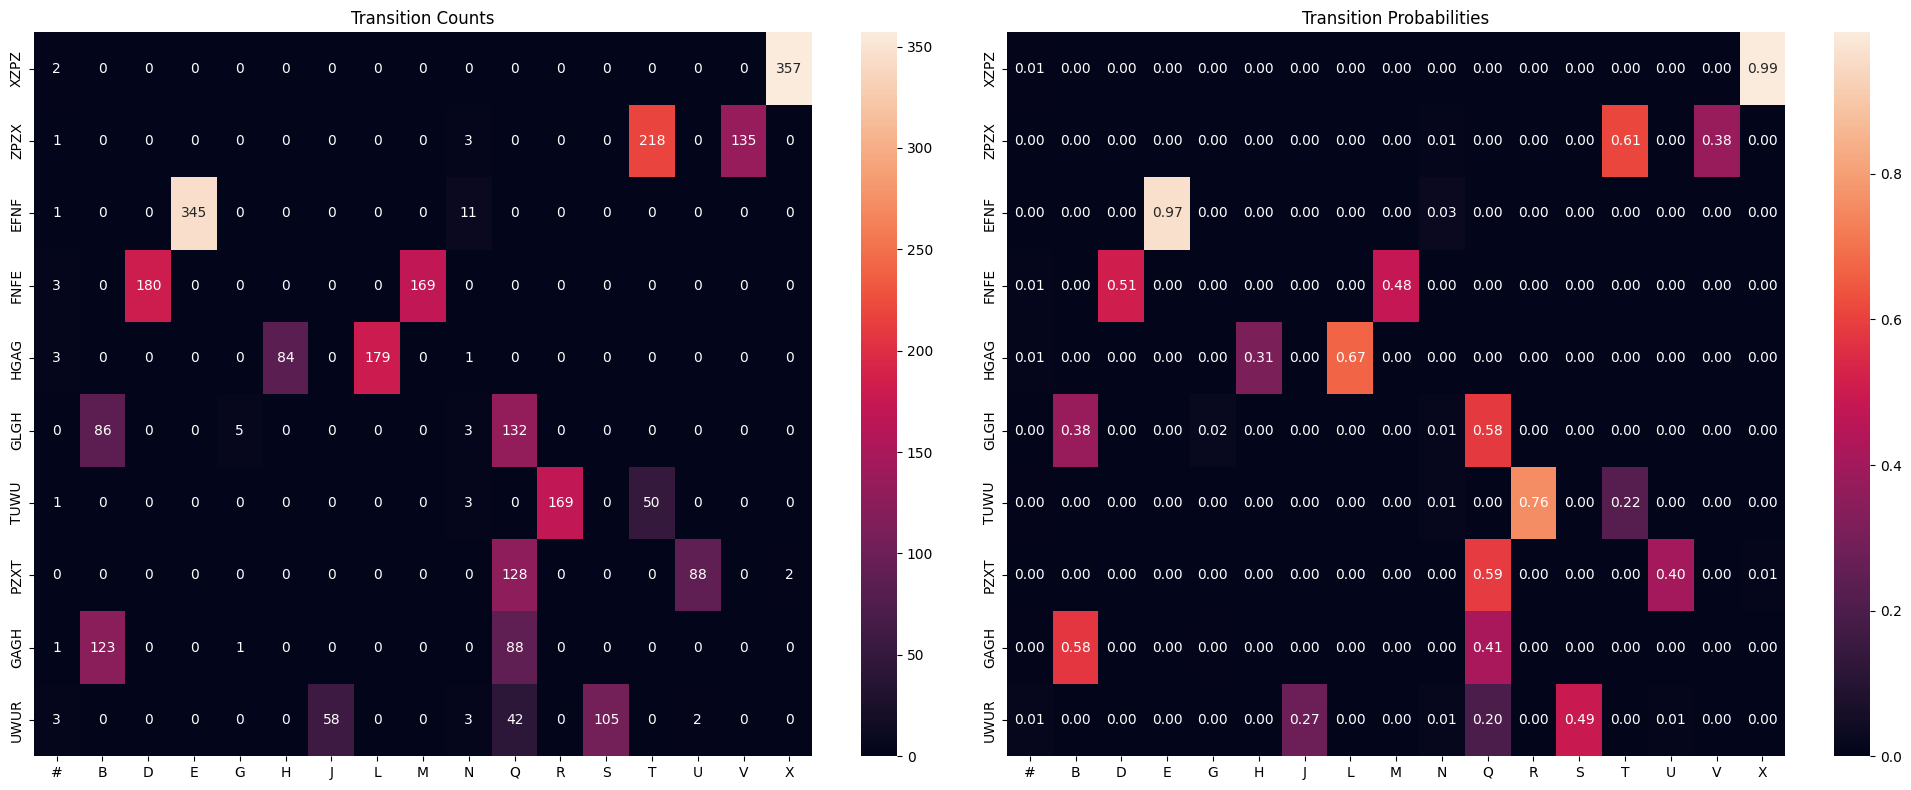

In [120]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_transition_heatmap(trajectories, window_size=3, top_k_contexts=10):
    trans_stats = compute_transition_probabilities(trajectories, window_size)
    
    # Get top contexts by total frequency
    sorted_contexts = sorted(trans_stats.items(), 
                           key=lambda x: x[1]['total'], 
                           reverse=True)[:top_k_contexts]
    
    # Prepare data for heatmap
    contexts = [context for context, _ in sorted_contexts]
    next_tokens = set()
    for _, stats in sorted_contexts:
        next_tokens.update(stats['counts'].keys())
    next_tokens = sorted(list(next_tokens))
    
    # Create matrix of counts or probabilities
    count_matrix = np.zeros((len(contexts), len(next_tokens)))
    prob_matrix = np.zeros((len(contexts), len(next_tokens)))
    
    for i, (context, stats) in enumerate(sorted_contexts):
        for j, token in enumerate(next_tokens):
            count_matrix[i, j] = stats['counts'].get(token, 0)
            prob_matrix[i, j] = stats['probs'].get(token, 0)
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    # Plot counts
    sns.heatmap(count_matrix, xticklabels=next_tokens, yticklabels=contexts, 
                annot=True, fmt='g', ax=ax1)
    ax1.set_title('Transition Counts')
    
    # Plot probabilities
    sns.heatmap(prob_matrix, xticklabels=next_tokens, yticklabels=contexts, 
                annot=True, fmt='.2f', ax=ax2)
    ax2.set_title('Transition Probabilities')
    
    plt.tight_layout()
    plt.show()

# Create visualization
plot_transition_heatmap(explore_df['explore_traj'].values, window_size=4)


## Try FLR + tokenisation, OVER simplified motifs

In [114]:
def simplify_path_frl(path):
    nodes_visited = path.split()[:-1]
    
    simplified = ""
    for i in range(len(nodes_visited)-1):
        rt = {1:2, 2:3, 3:4, 4:1}
        lt = {2:1, 1:4, 4:3, 3:2}

        curr_node, next_node = nodes_visited[i], nodes_visited[i+1]
        if curr_node[0] != next_node[0]:
            # forward press
            simplified += "F"
        elif rt[int(curr_node[1])] == int(next_node[1]):
            # right turn
            simplified += "R"
        elif lt[int(curr_node[1])] == int(next_node[1]):
            # left turn
            simplified += "L"
        else:
            # print(curr_node, next_node)
            simplified += "R"
            ## N3 N1 spin
            # print("FUCK ME")
        
    return simplified


explore_df['frl_traj'] = explore_df['e_paths'].apply(lambda x: simplify_path_frl(x))
# explore_df['frl_traj']


In [115]:
# ... existing imports ...
from collections import defaultdict

def create_ngram_vocabulary(trajectories, min_freq=5):
    # Get most common bigrams and trigrams
    bigrams = Counter([traj[i:i+2] for traj in trajectories for i in range(len(traj)-1)])
    trigrams = Counter([traj[i:i+3] for traj in trajectories for i in range(len(traj)-2)])
    fourgrams = Counter([traj[i:i+4] for traj in trajectories for i in range(len(traj)-3)])
    fivegrams = Counter([traj[i:i+5] for traj in trajectories for i in range(len(traj)-4)])


    # Filter by minimum frequency
    common_bigrams = {k: v for k, v in bigrams.items() if v >= min_freq}
    common_trigrams = {k: v for k, v in trigrams.items() if v >= min_freq}
    common_fourgrams = {k: v for k, v in fourgrams.items() if v >= min_freq}
    common_fivegrams = {k: v for k, v in fivegrams.items() if v >= min_freq}

    # Combine all n-grams and sort by frequency
    all_ngrams = []
    for ngram, freq in common_bigrams.items():
        all_ngrams.append((ngram, freq, 'B'))
    for ngram, freq in common_trigrams.items():
        all_ngrams.append((ngram, freq, 'T'))
    for ngram, freq in common_fourgrams.items():
        all_ngrams.append((ngram, freq, 'F'))
    for ngram, freq in common_fivegrams.items():
        all_ngrams.append((ngram, freq, 'V'))
    
    # Sort by frequency (descending)
    all_ngrams.sort(key=lambda x: x[1], reverse=True)
    
    # Create vocabulary mapping
    vocab = {}
    for i, (ngram, freq, type_prefix) in enumerate(all_ngrams):
        vocab[ngram] = f'{type_prefix}{i}'
    
    return vocab

def simplify_trajectory(traj, vocab):
    simplified = traj
    # Replace longest n-grams first
    for ngram, token in sorted(vocab.items(), key=lambda x: len(x[0]), reverse=True):
        simplified = simplified.replace(ngram, f' {token} ')
        # print(simplified)
    return ' '.join(simplified.split())  # Clean up extra spaces

# Create vocabulary and simplify trajectories
vocab_frl = create_ngram_vocabulary(explore_df['frl_traj'].values)
explore_df['simplified_traj_frl'] = explore_df['frl_traj'].apply(lambda x: simplify_trajectory(x, vocab_frl))

# Print vocabulary mapping and example
print("Vocabulary Mapping:")
for ngram, token in list(vocab_frl.items())[:10]:  # Show first 10 mappings
    print(f"{token}: {ngram}")

print("\nExample Trajectory Simplification:")
print("Original:", explore_df['frl_traj'].iloc[0][:50], "...")
print("Simplified:", explore_df['simplified_traj_frl'].iloc[0][:50], "...")

# explore_df[["frl_traj", "explore_traj", "simplified_traj_frl"]]

Vocabulary Mapping:
B0: FR
B1: RF
B2: LF
B3: FL
B4: FF
T5: FRF
T6: FLF
T7: FFR
T8: LFL
T9: RFL

Example Trajectory Simplification:
Original: LFLFLFRFLLRFLFFFRFFFLFFLFLFLFFLFLFLFRFRFFRFFRFRFFR ...
Simplified: L V27 T9 V102 V35 T6 V27 B2 V27 L V31 T5 V31 V31 B ...


In [116]:
# Split all trajectories into tokens and count them
all_tokens = ' '.join(explore_df['simplified_traj_frl']).split()
token_counts = Counter(all_tokens)

# Print the 10 most common tokens with their counts
print("Most common tokens:")
for token, count in token_counts.most_common(10):
    print(f"{token}: {count} occurrences")

# If you want to see what the original n-grams were for these tokens
print("\nOriginal n-grams for top tokens:")
reverse_vocab = {v: k for k, v in vocab_frl.items()}
for token, count in token_counts.most_common(10):
    if token in reverse_vocab:
        print(f"{token} ({count} occurrences) = {reverse_vocab[token]}")
    else:
        print(f"{token} ({count} occurrences) = single character")

Most common tokens:
V27: 613 occurrences
V29: 417 occurrences
R: 302 occurrences
V35: 189 occurrences
V31: 189 occurrences
L: 169 occurrences
V30: 153 occurrences
V34: 152 occurrences
F: 115 occurrences
B1: 87 occurrences

Original n-grams for top tokens:
V27 (613 occurrences) = FLFLF
V29 (417 occurrences) = FRFLF
R (302 occurrences) = single character
V35 (189 occurrences) = FFRFF
V31 (189 occurrences) = FRFRF
L (169 occurrences) = single character
V30 (153 occurrences) = FLFRF
V34 (152 occurrences) = FRFFR
F (115 occurrences) = single character
B1 (87 occurrences) = RF


In [117]:
salient_node = "V27" # FLFLF "F11" # FFRF
frl_trajs = {1: [], 2: [], 3: [], 4: []}
for i, row in explore_df.iterrows():
    path = row["simplified_traj_frl"]
    q = row["quartile"]
    # print(path)
    simplified_path = path.split()
    # print(simplified_path)
    # break
    
    for i in range(len(simplified_path)):
        if salient_node == simplified_path[i]: # in path[i]:# if i%5 == 0:
            if not pd.isna(q): 
                frl_trajs[q].append(simplified_path[i: i+10])
    

Statistical significance tests (Kruskal-Wallis H-test):

Number of Nodes:
H-statistic: 34.522
p-value: 0.000

Number of Edges:
H-statistic: 34.522
p-value: 0.000

Tree Depth:
H-statistic: 78.340
p-value: 0.000

Average Degree:
H-statistic: 34.522
p-value: 0.000

Diameter:
H-statistic: 118.149
p-value: 0.000

Number of Leaves:
H-statistic: 43.188
p-value: 0.000

Average Path Length:
H-statistic: 163.615
p-value: 0.000

Average Branching Factor:
H-statistic: 34.522
p-value: 0.000



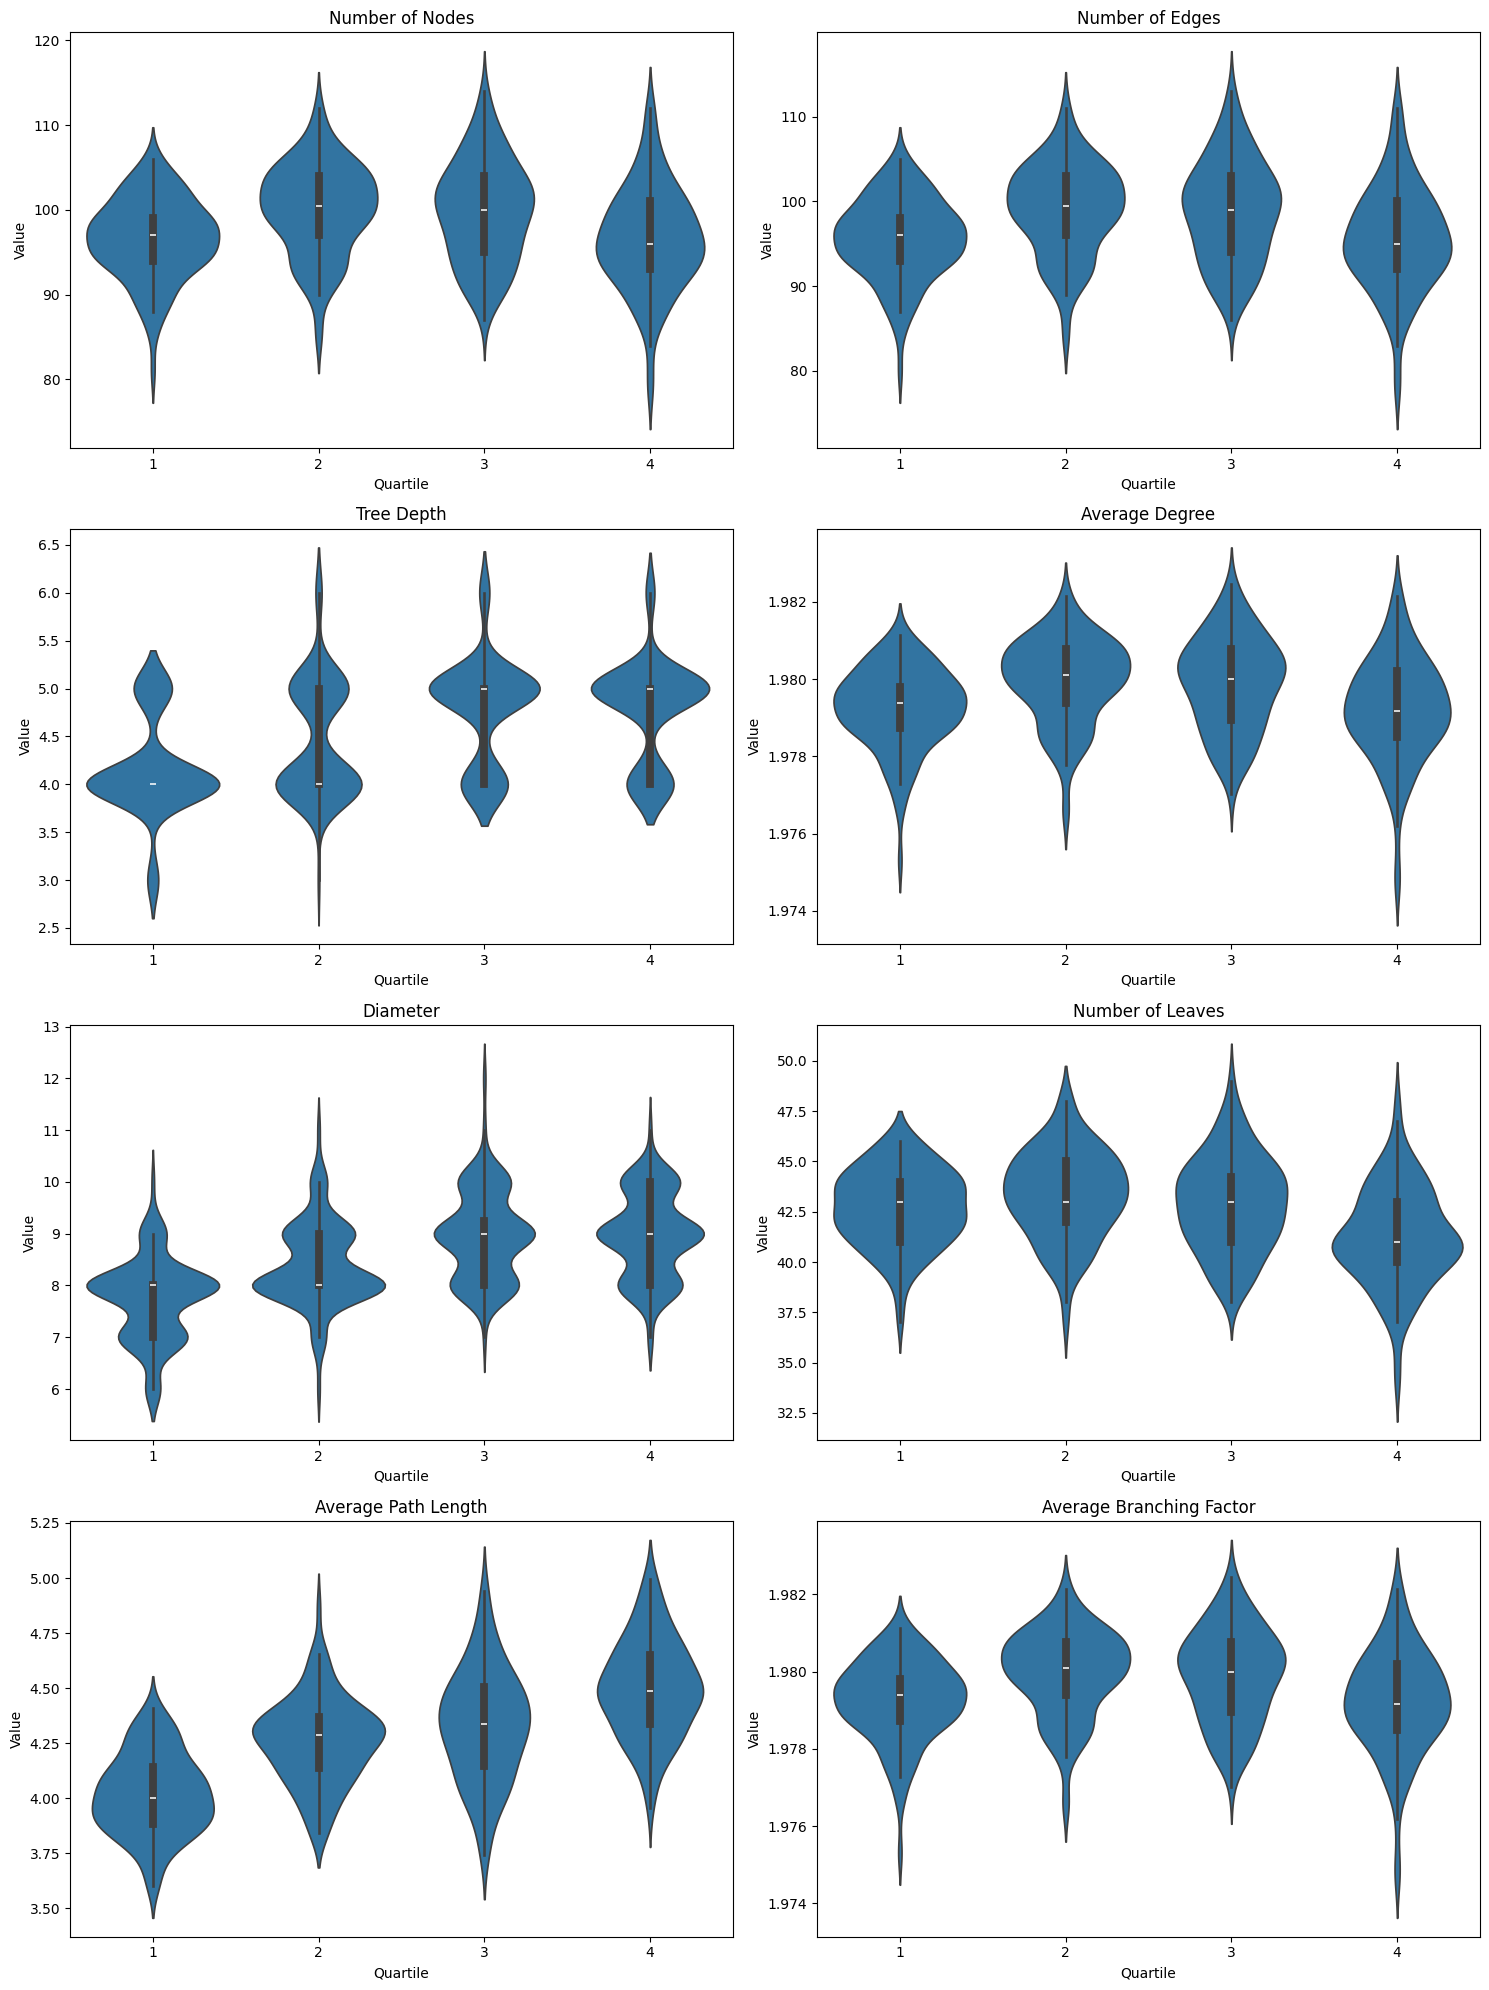

In [118]:
def generate_bootstrap_trees(quartile_trajs, n_bootstraps=100, sample_size=50):
    """Generate multiple trees via bootstrap sampling and extract their features."""
    bootstrap_features = []
    
    for _ in range(n_bootstraps):
        # Sample with replacement
        sampled_trajs = random.choices(quartile_trajs, k=min(sample_size, len(quartile_trajs)))
        
        # Generate tree
        G = nx.Graph()
        G.add_node(salient_node + "_0", color="red", end=False)
        
        visited = {}
        generate_reeb_tree(0, salient_node, sampled_trajs, 
                          [i for i in range(len(sampled_trajs))], 
                          G, visited, SUCCESS="IMPOSSIBLE", DEBUG=False)
        
        # Convert and extract features
        new_G = nx.relabel.convert_node_labels_to_integers(G)
        features = extract_tree_features(new_G, 0)
        bootstrap_features.append(features)
    
    return np.array(bootstrap_features)

# Generate bootstrap samples for each quartile
bootstrap_results = {}
for q in range(1, 5):
    if len(frl_trajs[q]) > 0:
        bootstrap_results[q] = generate_bootstrap_trees(frl_trajs[q])

# Statistical testing
from scipy import stats

# For each feature, perform statistical tests between quartiles
feature_names = [
    'Number of Nodes', 'Number of Edges', 'Tree Depth',
    'Average Degree', 'Diameter', 'Number of Leaves',
    'Average Path Length', 'Average Branching Factor'
]

print("Statistical significance tests (Kruskal-Wallis H-test):\n")
for i, feature in enumerate(feature_names):
    # Extract feature values for each quartile
    feature_by_quartile = [bootstrap_results[q][:, i] for q in range(1, 5) if q in bootstrap_results]
    
    # Perform Kruskal-Wallis H-test
    h_stat, p_val = stats.kruskal(*feature_by_quartile)
    
    print(f"{feature}:")
    print(f"H-statistic: {h_stat:.3f}")
    print(f"p-value: {p_val:.3f}\n")

# Plotting distributions of features
fig, axs = plt.subplots(4, 2, figsize=(15, 20))
axs = axs.ravel()

for i, feature in enumerate(feature_names):
    data = []
    for q in range(1, 5):
        if q in bootstrap_results:
            feature_vals = bootstrap_results[q][:, i]
            data.extend([(q, val) for val in feature_vals])

    df = pd.DataFrame(data, columns=['Quartile', 'Value'])

    sns.violinplot(data=df, x='Quartile', y='Value', ax=axs[i])
    axs[i].set_title(feature)

plt.tight_layout()
plt.show()


In [249]:
def compute_transition_probabilities(trajectories, window_size=3):
    """
    Compute both counts and conditional probabilities P(next_token | context)
    Returns both raw counts and probabilities
    """
    # Track raw counts
    context_counts = defaultdict(lambda: defaultdict(int))
    context_totals = defaultdict(int)
    
    # Count transitions
    for traj in trajectories:
        for i in range(len(traj) - window_size):
            context = traj[i:i+window_size]
            next_token = traj[i+window_size]
            
            context_counts[context][next_token] += 1
            context_totals[context] += 1
    
    # Convert to probabilities while keeping counts
    transition_stats = defaultdict(lambda: {'counts': {}, 'probs': {}, 'total': 0})
    
    for context in context_counts:
        transition_stats[context]['total'] = context_totals[context]
        for next_token in context_counts[context]:
            count = context_counts[context][next_token]
            prob = count / context_totals[context]
            
            transition_stats[context]['counts'][next_token] = count
            transition_stats[context]['probs'][next_token] = prob
    
    return transition_stats

# Example usage and pretty printing
def print_transition_stats(trajectories, window_size=3, top_k=3):
    trans_stats = compute_transition_probabilities(trajectories, window_size)
    
    print(f"\nTop {top_k} transitions for each context:")
    print("-" * 50)
    
    # Sort contexts by total frequency
    sorted_contexts = sorted(trans_stats.items(), 
                           key=lambda x: x[1]['total'], 
                           reverse=True)
    
    for context, stats in sorted_contexts[:10]:  # Show top 10 contexts
        print(f"\nContext: {context} (occurred {stats['total']} times)")
        
        # Sort transitions by count
        sorted_trans = sorted(stats['counts'].items(), 
                            key=lambda x: x[1], 
                            reverse=True)
        
        for next_token, count in sorted_trans[:top_k]:
            prob = stats['probs'][next_token]
            print(f"  → {next_token}: {count} times ({prob:.3f})")

# Run the analysis
print_transition_stats(explore_df['frl_traj'].values, window_size=2)



Top 3 transitions for each context:
--------------------------------------------------

Context: FR (occurred 3108 times)
  → F: 2584 times (0.831)
  → L: 266 times (0.086)
  → R: 258 times (0.083)

Context: RF (occurred 3099 times)
  → L: 1066 times (0.344)
  → F: 1058 times (0.341)
  → R: 975 times (0.315)

Context: LF (occurred 3045 times)
  → L: 1102 times (0.362)
  → R: 978 times (0.321)
  → F: 965 times (0.317)

Context: FL (occurred 3015 times)
  → F: 2569 times (0.852)
  → R: 272 times (0.090)
  → L: 174 times (0.058)

Context: FF (occurred 2837 times)
  → R: 1165 times (0.411)
  → L: 852 times (0.300)
  → F: 820 times (0.289)

Context: RR (occurred 447 times)
  → F: 262 times (0.586)
  → R: 112 times (0.251)
  → L: 73 times (0.163)

Context: RL (occurred 374 times)
  → F: 282 times (0.754)
  → L: 71 times (0.190)
  → R: 21 times (0.056)

Context: LR (occurred 363 times)
  → F: 248 times (0.683)
  → R: 79 times (0.218)
  → L: 36 times (0.099)

Context: LL (occurred 335 times)
